Created on Tue March 11 16:38:45 2025

Notebook for force measurement - article 0

1. import libraries and new (corrected) exp2 functions
2. import main excel file data
3. import tracking data (support position, contact position,2 stem points near support)
4. import results from root_stem_extractor?
5. a. remove problematic events from raw data
5. b. get event types from excel: close2axis, multi-twine, simple twine/slip
6. populate event-class variables
9. figures:
    1. example: 
        a. X,Y,Z position of support
        b. X,Y,Z position of contact?
        c. angle of support
        d. Force trajectory
    2. Calibration and noise
    3. Angle and force trajectories per support mass
    4. CN distribution?
    5. Force derivative plots?


@author: Amir Ohad

In [1]:
# import libraries
# general
import sys
import numpy as np
import os,glob # for listing files in folder
import re # regular expressions
import pandas as pd
import scipy
import math as m
from tqdm import tqdm
import shutil
import cv2

# plots
import importlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

# Plant and Event function file
import article0_funcs
importlib.reload(article0_funcs)

# plot parameters
cmap = plt.get_cmap('viridis')
fs = 16 # standard font size for plots


print(os.getcwd())
Article_folder = os.getcwd()

save_folder = os.path.join(Article_folder,'test_Figures')

# sys.path.append('..')
# import useful_functions as uf 
# importlib.reload(uf)
# Article_folder = r'C:\Users\Amir\Documents\PHD\Thesis\My Articles\0 - Flexible dynamic force measurement method via physical pendulum'
# importlib.reload(article0_funcs_clean)


c:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Repo_article0


In [2]:
# Define functions for plots

def round_to_first_significant_digit(num):
    if num == 0:
        return 0
    
    # Find the order of magnitude (e.g., for 456, magnitude is 10^2)
    magnitude = m.floor(m.log10(abs(num)))
    
    # Normalize the number to have its first significant digit as the most significant
    normalized_num = num / (10 ** magnitude)
    
    # Round to 1 significant digit
    rounded_num = round(normalized_num, 1)
    
    # Scale the number back to the original magnitude
    return rounded_num * (10 ** magnitude)

def set_grid(ax,x_range,y_range): 

    '''set grid for plot. take 1/5 of each range for major grid, 1/10 for minor'''
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in', length=5,
                   width=1, colors='black', grid_color='gray', grid_alpha=0.7)
    # Set major and minor grid spacing for x-axis and y-axis
    x_major_locator = plt.MultipleLocator(x_range / 5)
    x_minor_locator = plt.MultipleLocator(x_range / 10)
    y_major_locator = plt.MultipleLocator(y_range / 5)
    y_minor_locator = plt.MultipleLocator(y_range / 10)

    ax.xaxis.set_major_locator(x_major_locator)
    ax.xaxis.set_minor_locator(x_minor_locator)
    ax.yaxis.set_major_locator(y_major_locator)
    ax.yaxis.set_minor_locator(y_minor_locator)

    # Set major and minor tick labels with rounding to the first significant digit
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{round_to_first_significant_digit(x):g}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{round_to_first_significant_digit(y):g}'))

def linfunc(x,a,b): return a*x + b

def funcget_tracked_data(filename,view=[],camera='nikon'):
    '''get tracked data from file, return x,y,t, index, N- # of lines, C-max tracked obj,T-# of points per track'''
    with open(filename,"r") as datafile:
        lines= datafile.readlines()
        # del lines[0] # remove first line to avoid 2 zero times
        N=np.size(lines,0) # number of lines
        xtl=[[]]*N # x top left
        ytl=[[]]*N # y top left
        w=[[]]*N # box width
        h=[[]]*N # box height
        xcntr=[[]]*N # box x center
        ycntr=[[]]*N # box y center
        timer = np.zeros(N) # initialize timer array
        timer[0]=0 # time starts at zero
        i=0 # count rows
        index = 0
    # x,y,w,h ; start at upper left corner
        for line in lines:
            if line==[]: break
            currentline = line.split(",") # split by ','
            xtl[i]=float(currentline[0]) # xtl- x top left
            ytl[i]=float(currentline[1])
            w[i]=float(currentline[2])
            h[i]=float(currentline[3])
            xcntr[i]=xtl[i]+w[i]/2 # calculate x coordinate of box center
            ycntr[i]=ytl[i]-h[i]/2
            i+=1
            if i%50 ==0: 
                print(i)
                print(currentline)

        # timer = np.zeros(N) # initialize timer array
        dt = 1 # interval
        for i in range(N):
            timer[i] = timer[i-1]+dt # assign timer value for each index
        return xcntr,ycntr,timer,index,N
    
def fit_w_err(ax,x,dx,y,dy,fit_func = linfunc, data_color = 'blue',
              fit_color = 'red',add_legend = False, legend_loc='best',data_alpha=0.5):
    '''Fit data to the provided function and plot with error bars.

    Parameters:
    ax : matplotlib axis object
    x, dx : array-like, data and errors in x
    y, dy : array-like, data and errors in y
    fit_func : callable, function to fit the data
    data_color : str, color for the data points
    fit_color : str, color for the fitted curve
    legend_loc : str, location for the legend
    to_print : bool, whether to print function parameters on the plot

    Returns:
    popt : array, optimal values for the parameters
    pcov : 2D array, the estimated covariance of popt
    goodness of fit: R^2 and chi^2_red
    '''
    # Plot the data with error bars
    if add_legend: label_data='Data'
    else: label_data=None
    ax.errorbar(x, y, xerr=abs(dx), yerr=abs(dy), fmt='+',
                color=data_color,label=label_data, alpha=data_alpha)
    # fit with errors via curve fit
    popt,pcov = scipy.optimize.curve_fit(fit_func, x, y,
            p0=None, sigma=np.sqrt(dx**2+dy**2), absolute_sigma=True)
    ax.plot(x,(fit_func(x,*popt)),color=fit_color,
            label='Fit')#fit_func(x,*popt))

    # goodness of fit
    ss_total = np.sum((y - np.mean(y)) ** 2)
    line_of_best_fit = popt[0] * x + popt[1] # fit_func(x, *popt)
    residuals = y - line_of_best_fit
    ss_residual = np.sum(residuals**2)
    chi_squared_red = np.sum(residuals**2 / (dy**2+dx**2))/(len(x)-3)
    chi_sr_std = np.sqrt(2/(len(x)-3))
    r_squared = 1 - (ss_residual / ss_total)
    # need to fix printing of fitted values and goodness of fit for non-linear functions:
    # ax.plot(x,popt[0]*x+popt[1],'-',color=fit_color,
    #          label=rf'$\chi^{2}={chi_squared_red:.2f}, R^{2}: {r_squared:.2f}$,\
    #                  y = {popt[0]:.2f}x + {popt[1]:.2f} ')

    # upper =(popt[0]+np.diag(pcov)[0])*x+popt[1]+np.diag(pcov)[1]
    # lower = (popt[0]-np.diag(pcov)[0])*x+popt[1]-np.diag(pcov)[1]
    # ax.fill_between(np.arange(min(x),max(x),(max(x)-min(x))/len(x)),lower,upper)
    if add_legend: ax.legend(loc=legend_loc)
    # print(rf'{popt=},{pcov=},{chi_squared_red=:.2e},{chi_sr_std=:.2e},{r_squared=:.2e}')
    return popt,pcov,r_squared,chi_squared_red

# after reading both images, add to each a small size reference bar at the bottom left of each image, add a "1 cm" text above each bar. then continue the rest the same
def display_images_with_graph3(
    images1, coords1, images2, coords2, graph_data, fps=2, fixed_height=600, save_video=False, output_path="output_video.mp4"):
    if len(images1) != len(coords1) or len(images2) != len(coords2) or len(images1) != len(graph_data):
        raise ValueError("The number of images, coordinates, and graph data points must match.")

    delay = 1 / fps
    window_name = "Image Viewer"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

    video_writer = None  # Will be initialized after first frame

    for idx, (img1, coord1, img2, coord2, (x_vals, y_vals)) in enumerate(zip(images1, coords1, images2, coords2, graph_data)):
        # Load images if they are file paths
        img1 = cv2.imread(img1) if isinstance(img1, str) else img1
        img2 = cv2.imread(img2) if isinstance(img2, str) else img2

        # Convert grayscale to BGR
        if len(img1.shape) < 3:
            img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
        if len(img2.shape) < 3:
            img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

        # Add reference bar and text to each image
        bar_length1 = 450  # Length of the bar in pixels
        bar_length2 = 120
        bar_thickness = 20  # Thickness of the bar
        text_offset = 40  # Offset for the text above the bar
        text_size1 = 3.5
        text_thickness1 = 7
        text_size2 = 3
        text_thickness2 = 6
        # Add bar and text to img1
        cv2.rectangle(img1, (20, img1.shape[0] - 20), (10 + bar_length1, img1.shape[0] - 20 - bar_thickness), (0, 0, 0), -1)
        cv2.putText(img1, "1cm", (10, img1.shape[0] - 30 - text_offset), cv2.FONT_HERSHEY_SIMPLEX, text_size1, (0, 0, 0), text_thickness1)

        # Add bar and text to img2
        cv2.rectangle(img2, (20, img2.shape[0] - 20), (10 + bar_length2, img2.shape[0] - 20 - bar_thickness), (255,255,255), -1)
        cv2.putText(img2, "1cm", (10, img2.shape[0] - 30 - text_offset), cv2.FONT_HERSHEY_SIMPLEX, text_size2, (255, 255, 255), text_thickness2)

        # Draw current and past markers
        if coord1:
            cv2.circle(img1, (int(coord1[0]), int(coord1[1])), radius=15, color=(0, 165, 255), thickness=-1)
        if coord2:
            cv2.circle(img2, (int(coord2[0]), int(coord2[1])), radius=15, color=(0, 165, 255), thickness=-1)
        for prev_coord1 in coords1[:idx]:
            cv2.circle(img1, (int(prev_coord1[0]), int(prev_coord1[1])), radius=12, color=(255, 0, 0), thickness=-1)
        for prev_coord2 in coords2[:idx]:
            cv2.circle(img2, (int(prev_coord2[0]), int(prev_coord2[1])), radius=12, color=(255, 0, 0), thickness=-1)

        # Resize images to fixed height
        img1 = cv2.resize(img1, (int(img1.shape[1] * fixed_height / img1.shape[0]), fixed_height))
        img2 = cv2.resize(img2, (int(img2.shape[1] * fixed_height / img2.shape[0]), fixed_height))

        # Combine images horizontally
        combined_image = cv2.hconcat([img1, img2])

        # Create graph using matplotlib
        fig, ax = plt.subplots(figsize=(8, 4))
        plt.subplots_adjust(left=0.2, right=0.9, top=0.9, bottom=0.2)
        ax.plot(x_vals, y_vals, marker="o", color='orange', linewidth=1.5)
        for prev_x_vals, prev_y_vals in graph_data[:idx]:
            ax.plot(prev_x_vals, prev_y_vals, marker="o", color='blue', linewidth=1.5)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Force (mN)", labelpad=15, fontsize=12)
        max_x = max(graph_data, key=lambda x: x[0])[0]
        max_y = max(graph_data, key=lambda x: x[1])[1]
        ax.set_xlim([0, max_x * 1.1])
        ax.set_ylim([0, max_y * 1.1])
        ax.grid(True)

        canvas = FigureCanvas(fig)
        canvas.draw()
        graph_img = np.frombuffer(canvas.tostring_rgb(), dtype="uint8")
        graph_img = graph_img.reshape(canvas.get_width_height()[::-1] + (3,))
        plt.close(fig)

        # Resize graph to match image width
        scale_ratio = combined_image.shape[1] / graph_img.shape[1]
        graph_img = cv2.resize(graph_img, (combined_image.shape[1], int(graph_img.shape[0] * scale_ratio)))

        # Convert graph image to BGR for OpenCV
        graph_img = cv2.cvtColor(graph_img, cv2.COLOR_RGB2BGR)

        # Combine image and graph vertically
        final_frame = cv2.vconcat([combined_image, graph_img])

        # Display
        cv2.resizeWindow(window_name, final_frame.shape[1], final_frame.shape[0])
        cv2.imshow(window_name, final_frame)

        # Initialize writer on first frame (ensures correct resolution)
        if save_video and video_writer is None:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            frame_height, frame_width = final_frame.shape[:2]
            video_writer = cv2.VideoWriter(
                output_path,
                cv2.VideoWriter_fourcc(*"mp4v"),
                fps,
                (frame_width, frame_height),
            )

        # Write to video
        if save_video:
            video_writer.write(final_frame)

        # Wait for next frame
        if idx == len(images1) - 1:
            print("Final frame displayed. Close the window to end.")
            cv2.waitKey(0)
        else:
            cv2.waitKey(int(delay * 1000))

    if save_video and video_writer:
        video_writer.release()

    cv2.destroyAllWindows()


In [3]:
# import data 

data_path = os.path.join(Article_folder,'Data')

excel_path = r'\Exp2_supplementary_measurements_events_xl.xlsx'

# straw exp data
data_panda = pd.read_excel(data_path+excel_path)

# import tracked data, initiate variables
track_sup_path = r'\track_logs'
track_folder_path = data_path+track_sup_path

track_contact_path = r'\contact_track_logs'
contact_folder_path = data_path+track_contact_path


N_track = len(os.listdir(track_folder_path)) # get number of files in track folder
N_contact=len(os.listdir(contact_folder_path)) # get number of files in contact folder
N_tot = len(data_panda) # get number of lines in excel


#%% remove problematic events from raw data
delete_rows = [] # save rows to delete
problem_exp = [] # exp_num of problem events

for i in range(N_tot): # remove problem events and non-Helda events
    if data_panda.at[i,'problem']!='na' or data_panda.at[i,'Bean_Strain']!='Helda':
        delete_rows.append(i)
        problem_exp.append(data_panda.at[i,'Exp_num'])
N = N_tot - len(delete_rows) # modify num of rows

data_panda = data_panda.drop(data_panda.index[delete_rows]) # remove prob. events
data_panda = data_panda.reset_index() # redo index

#%% get misc. file lists

# get track files for support bottom coordinates
remove_chars = re.compile('[,_\.!?]') # what to remove from strings
track_dict = {} # save support track in dictionary by exp and events
i=0 # start with first track file
for file in glob.glob(os.path.join(track_folder_path, '*.txt')): # for each event:
    exp = int(re.findall('_\d{3,4}_',file)[0].replace('_','')) # find exp number (3-4 digits)
    event = int(re.findall('[0-9]',re.findall('_\d{1}\D',file)[0].replace('_',''))[0]) # find event number
    viewt = re.findall('(side{1}|top{1})',file)[0] #.replace('_','')
    track_dict[(exp,event,viewt)] = [file] # add new exp
    i+=1

# get track files for stem-support contact coordinates
contact_dict = {} # save support contact track in dictionary by exp and events
i=0 # start with first contact file
for file in glob.glob(os.path.join(contact_folder_path, '*.txt')): # for each event:
    exp = int(re.findall('_\d{3,4}_',file)[0].replace('_','')) # find exp number (3-4 digits)
    event = int(re.findall('_[0-9]_',file)[0].replace('_','')) # find event number
    contact_dict[(exp,event)] = [file] # add new exp
    i+=1


# root_path = r'C:\Users\Amir\Documents\PHD\Experiments\Force Measurements'
# basepath = root_path+r'\Exp2_Pendulum' # pendulum exp folder
# excel_csv= r'\Exp2_supplementary_measurements_events.csv'
# data_panda = pd.read_csv(basepath+excel_csv)
# track_near_sup_path = r'\twine_init_logs'
# track_near_sup_folder_path = basepath+track_near_sup_path
# h5_path = r'\Measurements\root_stem_results'
# h5_folder_path = basepath+h5_path
# E_path = r'\Young_moduli'
# E_folder_path = basepath+E_path
# N_E = len(os.listdir(E_folder_path))

# get track files for 2 stem positions on either side of support
# near_sup_track_dict = {}
# i=0 # start with first stem_near_sup file
# for file in glob.glob(os.path.join(track_near_sup_folder_path, '*.txt')): # for each event:
#     exp = int(re.findall('_\d{3,4}_',file)[0].replace('_','')) # find exp number (3-4 digits)
#     event = int(re.findall('_[0-9]_',file)[0].replace('_','')) # find event number
#     near_sup_track_dict[(exp,event)] = [file] # add new exp
#     i+=1

# get h5 files for stem near support
# h5_dict = {}
# i=0 # start with first h5 file
# for file in glob.glob(os.path.join(h5_folder_path, '*.h5')): # for each event:
#     exp = int(re.findall('interekt_\d{2,3}_',file)[0].split('_')[1]) # find exp number (3-4 digits)
#     event = int(re.findall('e_[0-9]_',file)[0].split('_')[1]) # find event number
#     start_frame = int(re.findall('_\d{2,5}-\d{2,5}',file)[0].replace('_','').split('-')[0]) # find start frame
#     h5_dict[(exp,event,start_frame)] = [file] # add new exp
#     i+=1

# get Young modulus files
# E_dict = {}
# for file in glob.glob(os.path.join(E_folder_path, '*.csv')):
#     exp = int(re.findall('\d{2,3}',file)[0])
#     E_dict[exp]=pd.read_csv(file,header=None)


<>:39: SyntaxWarning: invalid escape sequence '\.'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\.'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Amir\AppData\Local\Temp\ipykernel_2752\895611772.py:39: SyntaxWarning: invalid escape sequence '\.'
  remove_chars = re.compile('[,_\.!?]') # what to remove from strings
C:\Users\Amir\AppData\Local\Temp\ipykernel_2752\895611772.py:43: SyntaxWarning: invalid escape sequence '\d'
  exp = int(re.findall('_\d{3,4}_',file)[0].replace('_','')) # find exp number (3-4 digits)
C:\Users\Amir\AppData\Local\Temp\ipykernel_2752\895611772.py:44: SyntaxWarning: invalid escape sequence '\d'
  event = int(re.findall('[0-9]',re.findall('_\d{1}\D',file)[0].replace('_',''))[0]) # find event numbe

In [4]:
# clear plants and events
plants = []
events = []
#%% populate plant and event instances
i = 0
N = len(data_panda)
for i in tqdm(range(N)): # N
    try:
        exp = int(re.findall('\d{3,4}',data_panda.at[i,'Exp_num'])[0]) # exp num
        view = data_panda.at[i,'View']  # side of top view
        if view == 'top':
            plants[-1].pix2cm_t = float(data_panda.at[i,'Top_pix2cm'])

        if i==0 or exp!=plants[-1].exp_num: # append new plant with data from pandas
            #basic data
            plants.append(article0_funcs.Plant(data_panda,data_path,i,exp))
            # view dependent data
            plants[-1].view_data(data_panda,i)
            # circumnutation data
            plants[-1].cn_data(data_panda,i)
            #Youngs modulus by segment with avg
            # plants[-1].getE(E_dict)


        event =  int(re.findall('_[0-9]',data_panda.at[i,
        'Exp_num'])[0].replace('_','')) # get event number


        # if this is the 1st event or the previous event_num is different from the current one:
        # add new event to list
        if len(events)==0 or events[-1].event_num != event or \
            events[-1].p.exp_num != exp:
            events.append(article0_funcs.Event(plants[-1],data_panda,i))
        events[-1].event_num = event

        # view dependent data
        events[-1].view_data(data_panda,i,view)

        # get automated extraction of twine(decision) time
        # events[-1].get_twine_time(exp,event,view,
        #                   h5_dict,near_sup_track_dict,50,track_dict,to_plot=0)


        # get track data, select decision period data, pix2cm,
        events[-1].event_base_calcs(view,track_dict,contact_dict)
        # calc
        events[-1].event_calc_variables(view)
        # print(f'i={i}, exp number {exp}, {event}') # print progress
    except Exception as e:
        print(f'Error at i={i}, exp number {exp}, {event}')
        print(e)
        
        continue


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Amir\AppData\Local\Temp\ipykernel_2752\2092624545.py:9: SyntaxWarning: invalid escape sequence '\d'
  exp = int(re.findall('\d{3,4}',data_panda.at[i,'Exp_num'])[0]) # exp num
  6%|▋         | 21/324 [00:01<00:11, 27.50it/s]

new_y_pos_supp_bot(pixels) is NaN, using original support base z position


  9%|▉         | 29/324 [00:01<00:12, 23.66it/s]

new_y_pos_supp_bot(pixels) is NaN, using original support base z position


 13%|█▎        | 43/324 [00:01<00:09, 30.47it/s]

...

 74%|███████▍  | 240/324 [00:09<00:03, 24.72it/s]

new_y_pos_supp_bot(pixels) is NaN, using original support base z position


 81%|████████  | 261/324 [00:10<00:03, 19.50it/s]

new_y_pos_supp_bot(pixels) is NaN, using original support base z position


100%|██████████| 324/324 [00:13<00:00, 23.30it/s]


Slip:True exp:56, event:4


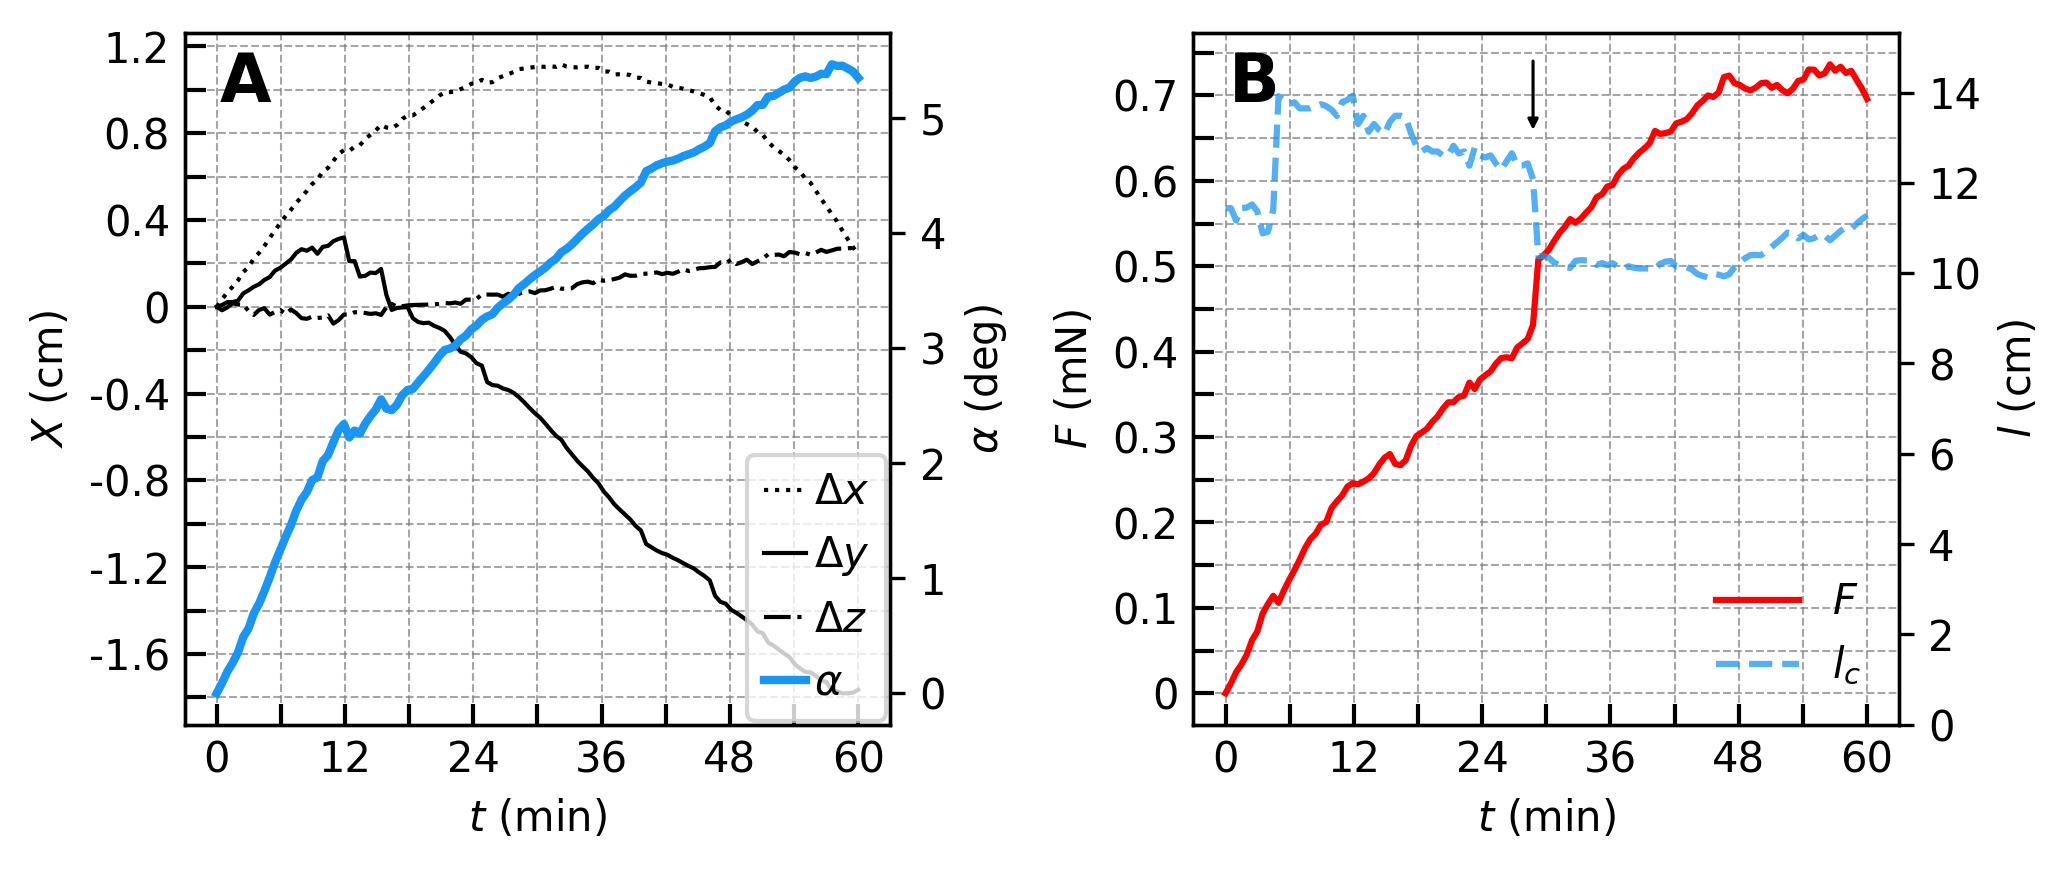

c:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Repo_article0\article0_funcs.py:454: RuntimeWarning: divide by zero encountered in divide
  dV_tr = (1/V_tr)*np.sqrt((x*sigma_top)**2 + (y*sigma_top)**2 +(z*sigma_side)**2)
c:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Repo_article0\article0_funcs.py:454: RuntimeWarning: invalid value encountered in multiply
  dV_tr = (1/V_tr)*np.sqrt((x*sigma_top)**2 + (y*sigma_top)**2 +(z*sigma_side)**2)
c:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Repo_article0\article0_funcs.py:461: RuntimeWarning: divide by zero encountered in divide
  alpha_err = np.tan(alpha) * np.sqrt((sigma_top/r_tr)**2 + 2*(sigma_side/(L-h))**2)
c:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Repo_article0\article0_funcs.py:461: RuntimeWarning: invalid value encountered in multiply
  alpha_err = np.tan(alpha) * np.sqrt((sigma_top/r_tr)**2 + 2*(sigma_side/(L-h))**2)
c:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Re

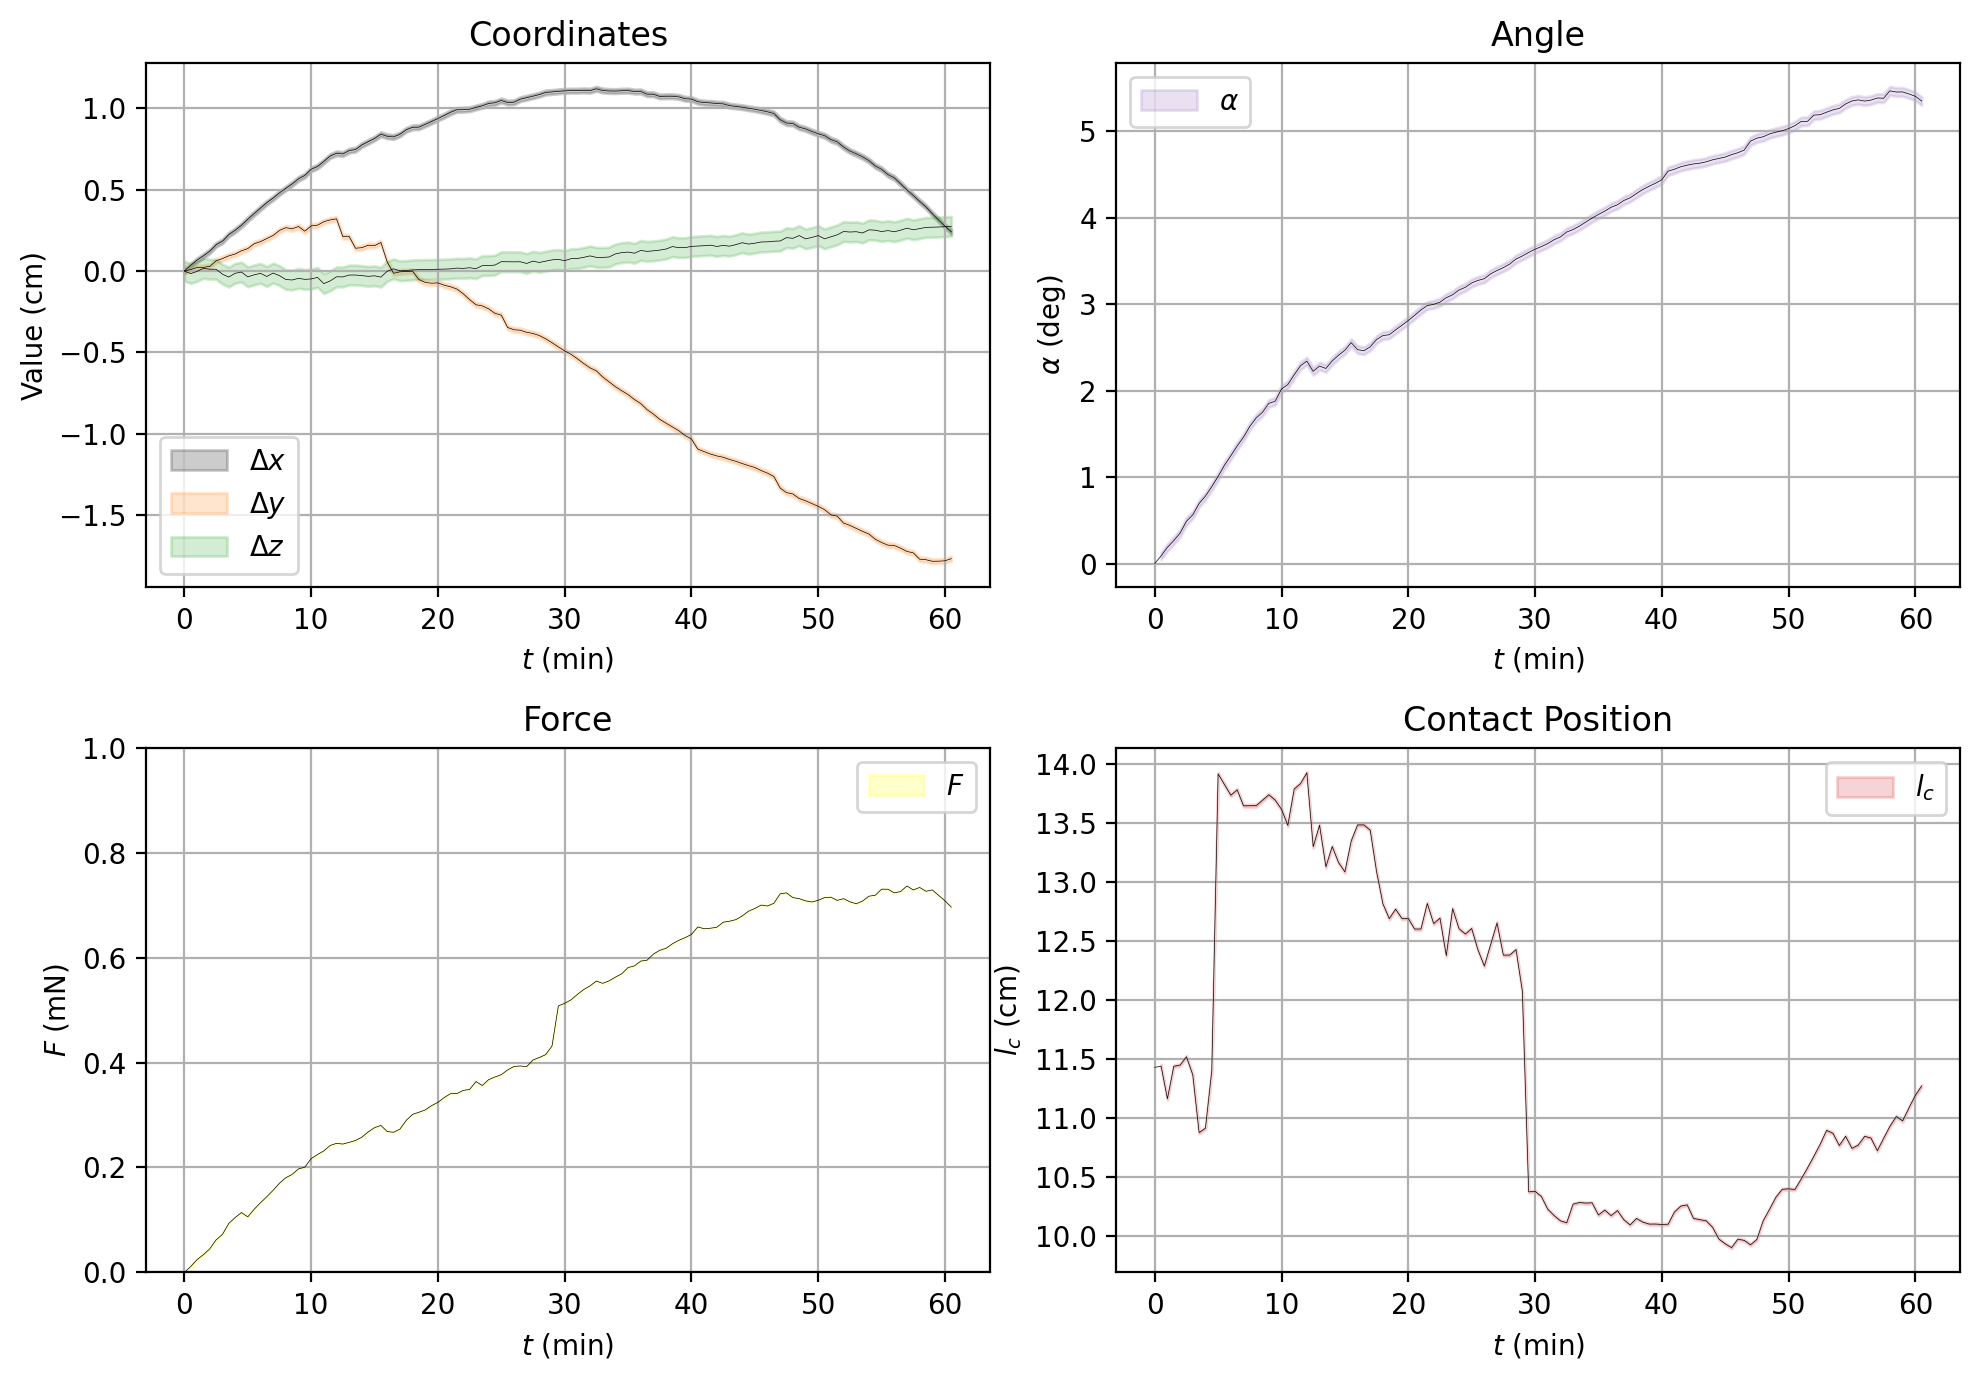

In [5]:
# Force trajectory for slip event with contact position along support
# cmap = plt.get_cmap('viridis')
cmap = plt.get_cmap('rainbow')
i_exmp = 60 # 40 (simple) , 20,120 (bump from dist2tip)
event_exmp = events[i_exmp]
max_time = event_exmp.timer[-1]/60

# check events are correctly classified
print("Slip:"+ str( event_exmp.twine_state==0),
      f"exp:{event_exmp.p.exp_num}, event:{event_exmp.event_num}")

fig, axs = plt.subplots(1, 2, figsize=(7, 3), dpi=300)
# add subplot labels
axs[0].text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=axs[0].transAxes)
axs[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=axs[1].transAxes)

# Plot xyz coordinates
xyz = event_exmp.xyz
axs[0].plot(event_exmp.timer/60, xyz[0,::]-xyz[0,0], color='black', 
            linestyle = 'dotted', linewidth = 1, label=r'$\Delta x$') #cmap(0.1)
axs[0].plot(event_exmp.timer/60, xyz[1,::]-xyz[1,0], color='black', 
            linestyle = '-', linewidth = 1, label=r'$\Delta y$') #cmap(0.5)
axs[0].plot(event_exmp.timer/60, xyz[2,::]-xyz[2,0], color='black', 
            linestyle = 'dashdot', linewidth = 1, label=r'$\Delta z$') #cmap(0.9)

# Plot angle on the same figure with different axis
axs0 = axs[0].twinx()
axs0.plot(event_exmp.timer/60, np.rad2deg(event_exmp.alpha), color=cmap(0.2), linewidth = 2, label=r'$\alpha$') #cmap(0.2)
# add legend label from the twin axis
lines, labels = axs[0].get_legend_handles_labels()
lines2, labels2 = axs0.get_legend_handles_labels()

# set axis and grid
axs[0].set_xlabel(r'$t$ (min)')
axs[0].set_ylabel(r'$X$ (cm)')
# axs0.set_ylim([0,10])
# set_grid(axs[0],max_time,5)
set_grid(axs[0],max_time,2)

# axs0.set_xlabel(r'$t$ (min)')
axs0.set_ylabel(r'$\alpha$ (deg)')

# Adjust the legend properties

axs[0].legend(
    lines + lines2, labels + labels2,
    loc='lower right',          # Place legend
    frameon=True,              # Remove the frame
    handlelength=1,             # Shorter line elements
    handletextpad=0.2,          # Reduce space between handle and text
    borderaxespad=0.1,          # Reduce space between legend and inset plot edge
    fontsize=10                 # Smaller font size for better fit
)


###########################################
# Plot calculated force and contact position

axs[1].plot(event_exmp.timer/60, event_exmp.F_bean,
             color=cmap(1.5), label=r'$F$') #cmap(0.2)
ax2 = axs[1].twinx()
dist2tip = [abs(k) for k in event_exmp.l_contact] # ?
# ax2.plot(event_exmp.timer/60, dist2tip, color='gray', label=r'$l$', alpha=0.75) # cmap(0.7)

# axs[1].vlines(event_exmp.timer[-1]/60, 0, event_exmp.F_bean[-1]*mg2mN,
#                color=cmap(1.5), linestyle='dotted')
ax2.plot(event_exmp.timer/60, dist2tip, color= cmap(0.2), linestyle='dashed',
          label=r'$l_c$', alpha=0.75)
lines, labels = axs[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axs[1].legend(lines + lines2, labels + labels2, loc='best',frameon=False)



# draw a small downward arrow at rapid force increase
x0 = 29
y0 = 0.65
axs[1].annotate(
    '',                    # no text
    xy=(x0, y0),           # arrow tip
    xytext=(x0, y0 + 0.1), # arrow tail (0.5 units above)
    arrowprops=dict(
        arrowstyle='-|>',  # simple arrow head
        lw=0.75,            # line width of arrow shaft
        mutation_scale=5, # size of arrow head
        color='black'
    )
)

ax2.set_ylabel(r'$l$ (cm)')
ax2.set_ylim([0,max(dist2tip)*1.1])
axs[1].set_xlabel(r'$t$ (min)')
axs[1].set_ylabel(r'$F$ (mN)')
set_grid(axs[1],max_time,0.5)
# set_grid(ax2,max_time,17.5)

plt.tight_layout()
plt.show()
# fig.savefig(save_folder+r'\xyz_ang_F_l_2.pdf',dpi=300)

# plot the errors for x,y,z shifts, the angle and the force
#  as shaded area around curves
x = event_exmp.xyz[0,::]-event_exmp.xyz[0,0]
y = event_exmp.xyz[1,::]-event_exmp.xyz[1,0]
z = event_exmp.xyz[2,::]-event_exmp.xyz[2,0]
z_c = event_exmp.z_cont_dec- event_exmp.z_cont_dec[0]
lc = event_exmp.l_contact
alpha = event_exmp.alpha
r_tr = event_exmp.r_tr_xy
k = event_exmp.pz

sigma_noise = 0.01 # cm
sigma_tr = 5 # pixels
rho_top = 0.002 # cm/pix
rho_side = 0.012 # cm/pix 
L = event_exmp.L_tracked_new
h = event_exmp.h_tip_new
dL = 0.01/np.sqrt(12)
mass = event_exmp.p.m_sup # in g, need to convert to mg or kg??
dmass = 0.01/np.sqrt(12) # 

F = event_exmp.F_bean
x_err, y_err, z_err, lc_err, alpha_err, F_err,dk = article0_funcs.calc_errors(
                x,y,z,z_c, sigma_noise, sigma_tr, rho_side, rho_top,k,
                alpha,r_tr,L,dL,h,F,mass,dmass,lc)


fig, axs = plt.subplots(2, 2, figsize=(10, 7), dpi=200)
t = event_exmp.timer/60  # convert to minutes
# 1. Plot x, y, z coordinates with errors
ax = axs[0, 0]
ax.plot(t, x, color='black', linewidth=0.25)
ax.fill_between(t, x - x_err, x + x_err, color='black', alpha=0.2, label=r'$\Delta x$')
ax.plot(t, y, color='black', linewidth=0.25)
ax.fill_between(t, y - y_err, y + y_err, color='tab:orange', alpha=0.2, label=r'$\Delta y$')
ax.plot(t, z, color='black', linewidth=0.25)
ax.fill_between(t, z - z_err, z + z_err, color='tab:green', alpha=0.2, label=r'$\Delta z$')
ax.set_xlabel(r'$t$ (min)')
ax.set_ylabel('Value (cm)')
ax.set_title('Coordinates')
ax.legend()
ax.grid(True)

# 2. Plot angle with error
ax = axs[0, 1]
ax.plot(t, np.rad2deg(alpha), color='black', linewidth=0.25)
if 'alpha_err' in locals():
    ax.fill_between(t, np.rad2deg(alpha - alpha_err), np.rad2deg(alpha + alpha_err), 
                    color='tab:purple', alpha=0.2, label=r'$\alpha$')
ax.set_xlabel(r'$t$ (min)')
ax.set_ylabel(r'$\alpha$ (deg)')
ax.set_title('Angle')
ax.legend()
ax.grid(True)

# 3. Plot force with error
ax = axs[1, 0]
ax.plot(t, F, color='black', linewidth=0.25)
if 'F_err' in locals():
    ax.fill_between(t, F - F_err, F + F_err, color='yellow', alpha=0.2,label=r'$F$')
ax.set_xlabel(r'$t$ (min)')
ax.set_ylabel(r'$F$ (mN)')
ax.set_ylim([0, 1])
ax.set_title('Force')
ax.legend()
ax.grid(True)

# 4. Plot l_contact with error
ax = axs[1, 1]
ax.plot(t, lc, color='black', linewidth=0.25)
ax.fill_between(t, lc - lc_err, lc + lc_err, color='tab:red', alpha=0.2,label=r'$l_c$')
ax.set_xlabel(r'$t$ (min)')
ax.set_ylabel(r'$l_c$ (cm)')
# ax.set_ylim([0, 15])
ax.set_title('Contact Position')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# Calculate relative error
relative_error = F_err / np.array(F)
# Skip the first value (often nan or unreliable) for plotting
F_plot = F[2:]
relative_error_plot = relative_error[2:]
t_plot = t[2:]

# Create a colormap for relative error
# cmap = plt.cm.viridis
# norm = plt.Normalize(vmin=abs(relative_error_plot.min()), vmax=abs(relative_error_plot.max()))

# # Plot the force trajectory with color-coded relative error
# fig, ax = plt.subplots(figsize=(10, 6))
# sc = ax.scatter(t_plot, F_plot, c=relative_error_plot, cmap=cmap, norm=norm, label='Force Trajectory')
# plt.colorbar(sc, label='Relative Error')
# ax.set_xlabel('Time (min)')
# ax.set_ylabel('Force (mN)')
# ax.set_title('Force Trajectory with Relative Error Color Coding')
# plt.legend()
# plt.show()

# # Overlay the relative error on the same plot
# fig, ax1 = plt.subplots(figsize=(10, 6))
# ax2 = ax1.twinx()
# ax1.plot(t_plot, F_plot, label='Force', color='blue')
# ax2.plot(t_plot, relative_error_plot, label='Relative Error', color='red', linestyle='--')
# ax1.set_xlabel('Time (min)')
# ax1.set_ylabel('Force (mN)', color='blue')
# ax2.set_ylabel('Relative Error', color='red')
# ax1.set_title('Force Trajectory with Relative Error Overlay')
# fig.tight_layout()
# plt.show()

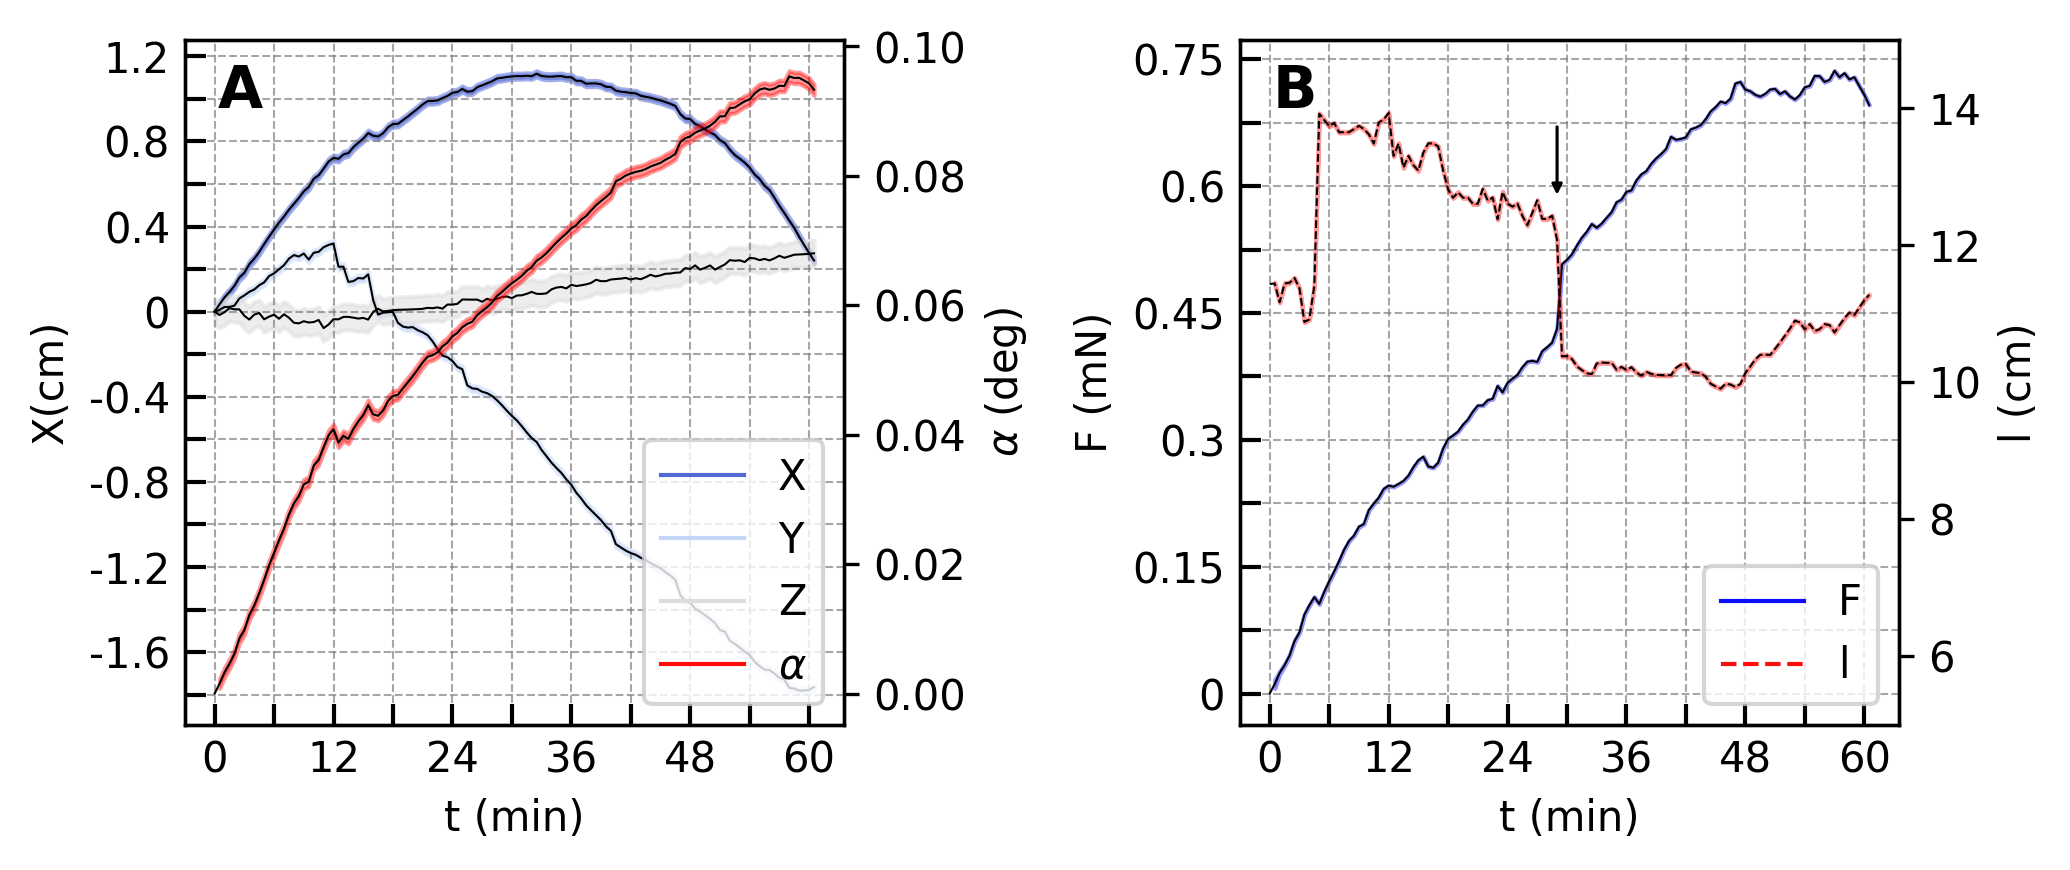

In [ ]:
# Figure xyz, alpha, F, lc, with errors

# Create a new figure with subplots for coord. angle and F/lc with error values
fig, axs = plt.subplots(1, 2, figsize=(7, 3),dpi=300)
# Add large subplot labels
axs[0].text(0.05, 0.9, 'A', fontsize=14, fontweight='bold', transform=axs[0].transAxes)
axs[1].text(0.05, 0.9, 'B', fontsize=14, fontweight='bold', transform=axs[1].transAxes)

# First subplot: coordinates (x, y, z) with error and angle (\alpha) on a second axis
ax1 = axs[0]
# Choose three colors along a cool-warm colorscheme using numbers for easy adjustment
color_x = plt.get_cmap('coolwarm')(0.05)
color_y = plt.get_cmap('coolwarm')(0.4)
color_z = plt.get_cmap('coolwarm')(0.5)

ax1.plot(t, x, color='black', linewidth=0.5)
ax1.fill_between(t, x - x_err, x + x_err, color=color_x, alpha=0.5, label=r'\Delta x')
ax1.plot(t, y, color='black', linewidth=0.5)
ax1.fill_between(t, y - y_err, y + y_err, color=color_y, alpha=0.5, label=r'\Delta y')
ax1.plot(t, z, color='black', linewidth=0.5)
ax1.fill_between(t, z - z_err, z + z_err, color=color_z, alpha=0.5, label=r'\Delta z')
ax1.set_xlabel('t (min)')
ax1.set_ylabel('X(cm)')
# ax1.tick_params(axis='both', labelsize=10)
set_grid(ax1,60,2)
 
# Add a second y-axis for the angle
ax1_alpha = ax1.twinx()
ax1_alpha.plot(t, alpha, color='black', linewidth=0.5)
ax1_alpha.fill_between(t, alpha - alpha_err, alpha + alpha_err, color='red', alpha=0.4, label='Angle')
ax1_alpha.set_ylabel(r'$\alpha$ (deg)')
ax1_alpha.tick_params(axis='y')


# Combine legends from error fill colors only
custom_lines1 = [
    Line2D([0], [0], color=color_x, lw=1, alpha=0.95, label=r'\Delta x'),
    Line2D([0], [0], color=color_y, lw=1, alpha=0.95, label=r'\Delta y'),
    Line2D([0], [0], color=color_z, lw=1, alpha=0.95, label=r'\Delta z'),
    Line2D([0], [0], color='red', lw=1, alpha=0.95, label=r'$\alpha$')
]
ax1.legend(handles=custom_lines1, loc='lower right',frameon=True)
 
# Second subplot: F and lc with error
ax2 = axs[1]
ax3 = ax2.twinx()
ax2.plot(t, F, color='black', linewidth=0.5)
ax2.fill_between(t, F - F_err, F + F_err, color='blue', alpha=0.4, label='F')
ax3.plot(t, lc,  linestyle = '--', color='black', linewidth=0.5)
ax3.fill_between(t, lc - lc_err, lc + lc_err, color='red', alpha=0.4, label='l')
ax2.set_xlabel('t (min)')
ax2.set_ylabel('F (mN)')
ax3.set_ylabel('l (cm)')
# ax2.tick_params(axis='both', labelsize=10)
# ax3.tick_params(axis='y', labelsize=10)
ax3.set_ylim([5, 15])
ax2.grid(alpha=0.5)

# draw a small downward arrow at rapid force increase
x0 = 29
y0 = 0.58
ax2.annotate(
    '',                    # no text
    xy=(x0, y0),           # arrow tip
    xytext=(x0, y0 + 0.1), # arrow tail (0.5 units above)
    arrowprops=dict(
        arrowstyle='-|>',  # simple arrow head
        lw=0.75,            # line width of arrow shaft
        mutation_scale=5, # size of arrow head
        color='black'
    )
)

# Set legend handles to lines (not rectangles) for error fills

custom_lines = [
    Line2D([0], [0], color='blue', lw=1, alpha=0.95, label='F'),
    Line2D([0], [0], color='red', lw=1, alpha=0.95, linestyle='--', label='l')
]
ax2.legend(handles=custom_lines, loc='lower right')
# Combine legends from error fill colors only
# lines3, labels3 = ax2.get_legend_handles_labels()
# lines4, labels4 = ax3.get_legend_handles_labels()
# ax2.legend(lines3 + lines4, labels3 + labels4, loc='lower right',frameon=False)
set_grid(ax2,60,0.75)

fig.tight_layout()
# plt.show()
fig.savefig(save_folder + r'\coord_angle_F_lc_err.svg', dpi=300)


50
['2619.0', ' 1991.0', ' 144.0', ' 116.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Calibrations\\fluctuations_1sec_int\\DSC_8205.JPG', ' 2024-05-11 13:07', ' 0', ' Auto\n']
100
['2640.0', ' 1994.0', ' 120.0', ' 97.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Calibrations\\fluctuations_1sec_int\\DSC_8255.JPG', ' 2024-05-11 13:08', ' 0', ' Auto\n']
pix2cm=0.0019 cm/pix,std_noise=0.096 mm
d_alpha_noise=0.00029 rad , np.rad2deg(d_alpha_noise)=0.016 deg
err_res_pix=7.1 cm/pix,err_res_mm=0.13 mm
D_mm=20 mm,dD_mm=0.16 mm,L_mm=1.8e+02 mm,dL_mm=0.13 mm,h_tip_mm=12 mm,      dh_tip_mm=0.13 mm,A=0.059,alpha_error_calc=0.0005 rad, F_min_mN=0.002 mN


C:\Users\Amir\AppData\Local\Temp\ipykernel_16416\1319385647.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


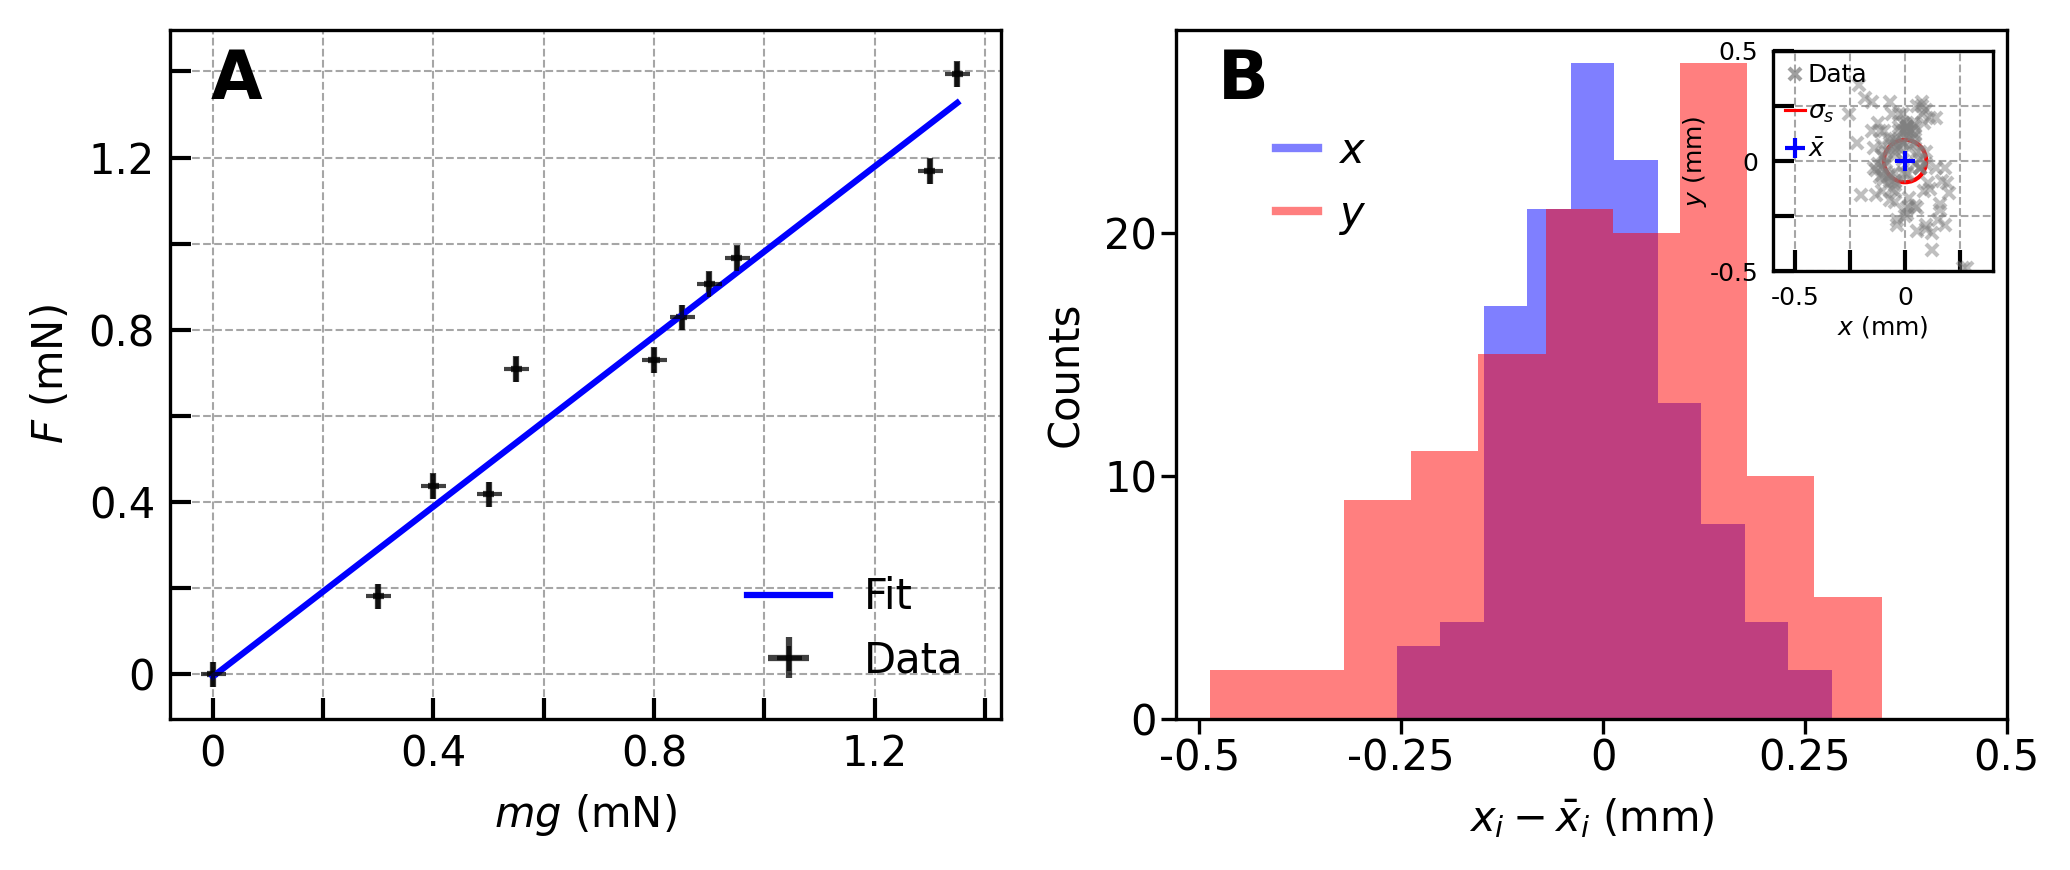

In [ ]:
# combined plot of calibration (A) and noise (B)

# test = r"C:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Repo_article0\CSRT_fluctuations_1sec_interval.txt"
fluctuation_track_file = os.path.join(data_path, r'fluctuations\CSRT_fluctuations_1sec_interval.txt')


xcntr,ycntr,timer,index,N = funcget_tracked_data(fluctuation_track_file)
pend_diam_pix = 423 # width of the pendulum from top view
pend_diam_cm = 0.8
L_cm = 18 
pix2cm = pend_diam_cm/pend_diam_pix 
L_mm = L_cm*10
h_tip = np.mean([events[i].L_track2suptip_cm for i in range(len(events))])
h_tip_mm = h_tip*10

fig, ax = plt.subplots(1, 2, figsize=(7, 3), dpi=300)
ax[0].text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=ax[0].transAxes)
ax[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax[1].transAxes)


############################################################
x = np.subtract(xcntr, np.mean(xcntr))*pix2cm*10 # x10 for mm
y = np.subtract(ycntr, np.mean(ycntr))*pix2cm*10 # x10 for mm

# Plot the distribution
ax[1].hist(x, alpha=0.5, color='blue', label=r'$x$')
ax[1].hist(y, alpha=0.5, color='red', label=r'$y$')
ax[1].set_xlabel(r'$x_{i} - \bar{x}_{i}$ (mm)')
ax[1].set_ylabel('Counts')
# Control x-tick and y-tick positions
ax[1].set_xticks([-0.5, -0.25, 0, 0.25, 0.5])  # Set specific tick positions
ax[1].set_xticklabels([-0.5, -0.25, 0, 0.25, 0.5], fontsize=10)  # Set specific tick labels with fontsize
ax[1].set_yticks([0, 10, 20])  # Set specific y-tick positions
ax[1].set_yticklabels([0, 10, 20], fontsize=10)  # Set specific y-tick labels with fontsize
# Adjust tick labels' padding
ax[1].tick_params(axis='x', pad=1)  # Move x-axis labels closer to the ticks
ax[1].tick_params(axis='y', pad=1)  # Move y-axis labels closer to the ticks

# Create a custom legend element for the noise distribution
legend_elements = [
    Line2D([0], [0], color='blue',alpha=0.5, lw=2, linestyle='-', label=r'$x$'),  # Data points
    Line2D([0], [0], color='red', lw=2, alpha=0.5, linestyle='-', label=r'$y$'),  # Straight red line
]
# ax[1].legend(loc='best',frameon=False)
# Add the custom legend elements to the plot
ax[1].legend(
    handles=legend_elements,
    loc='upper left',          # Place in the upper-right corner
    frameon=False,              # Remove the frame
    handlelength=1,             # Shorter line elements
    handletextpad=0.5,          # Reduce space between handle and text
    borderaxespad=2,          # Reduce space between legend and inset plot edge
    fontsize=10                 # Smaller font size for better fit
)


############################################################
# Create inset axes
ax_inset = inset_axes(ax[1], width="40%", height="40%",# loc='upper right',
                      bbox_to_anchor=(0.22, 0.2,0.82,0.8), bbox_transform=ax[1].transAxes)
ax_inset.set_ylim([-0.5,0.5])
ax_inset.set_xlim([-0.6,0.4])
ax_inset.set_xlabel(r'$x$ (mm)',fontsize=6,labelpad=1)
ax_inset.set_ylabel(r'$y$ (mm)',fontsize=6,labelpad=0)
ax_inset.tick_params(axis='both', length=2)  # Make both x and y axis ticks shorter
ax_inset.tick_params(axis='both', width=0.5)  # Make both x and y axis ticks thinner
ax_inset.tick_params(axis='both', labelsize=6)  # Make both x and y axis labels smaller
set_grid(ax_inset,2.5,2.5)

# Increase the x and y scales of the main plot
# ax[0].set_xlim([-0.4, 0.6])
# ax[0].set_ylim([-0.3, 0.6])
# Ensure the x and y axes are plotted on the same scale
ax_inset.set_aspect('equal', adjustable='box')

# calculate the mean and standard deviation of the data
# calculate mean
ax_inset.plot(x,y,'x',color='grey',alpha=0.5,label = 'Data',markersize=3)
# plot the mean
ax_inset.plot(np.mean(x),np.mean(y),'b+',markersize=5,label={r'$\bar{x}$'})
# calculate the std
std_noise = np.std(np.sqrt(x**2 + y**2)) # in mm
# Plot a thin red circle with a radius of the standard deviation around the mean
circle_noise = plt.Circle((np.mean(x), np.mean(y)), std_noise, color='red', fill=False, linewidth=1,label=r'$\sigma_{noise}$')
# Plot a thin red circle with a radius of the pendulum around the mean
circle_diameter = plt.Circle((np.mean(x), np.mean(y)), pend_diam_cm/2*10, color='red', fill=False, linewidth=0.5)
# plt.gca().add_artist(circle_diameter)
ax_inset.add_artist(circle_noise)

# Create a custom legend element for the noise and data
legend_elements = [
    Line2D([0], [0], marker='x', color='grey', markersize=3, alpha=0.75, linestyle='None', label='Data'),  # Data points
    Line2D([0], [0], color='red', lw=0.75, linestyle='-', label=r'$\sigma_{s}$'),  # Straight red line
    Line2D([0], [0], marker='+', color='blue', markersize=5, linestyle='None', label=r'$\bar{x}$') # mean point
]

# Adjust the legend properties
ax_inset.legend(
    handles=legend_elements,
    loc='upper left',          # Place in the upper-right corner
    frameon=False,              # Remove the frame
    handlelength=0.8,           # Shorter line elements
    handletextpad=0.1,          # Reduce space between handle and text
    borderaxespad=0.1,          # Reduce space between legend and inset plot edge
    fontsize=6                  # Smaller font size for better fit
)

############################################################
# errors
std_noise = np.std(np.sqrt(x**2 + y**2)) # in mm
print(f'{pix2cm=:.2g} cm/pix,{std_noise=:.2g} mm')
d_alpha_noise = m.asin((std_noise/2)/(L_mm-h_tip_mm))
print(f'{d_alpha_noise=:.2g} rad , {np.rad2deg(d_alpha_noise)=:.2g} deg')
# error from resolution:
# distance error is ssq of individual measurement errors ~ 2 pixels per measurement
trk_pix_err = 5 # pixel tracking error estimation 
err_res_pix = m.sqrt(trk_pix_err**2 + trk_pix_err**2)
err_res_mm = err_res_pix*pix2cm*10
print(f'{err_res_pix=:.2g} cm/pix,{err_res_mm=:.2g} mm')

# sum errors from resolution and noise:
D_mm = 20 # mean deflection in mm 
dD_mm = np.sqrt(std_noise**2 + (err_res_pix*pix2cm*10)**2) # in mm
dh_tip_mm = err_res_pix*pix2cm*10
dL_mm = err_res_pix*pix2cm*10
A = D_mm/(2*(L_mm-h_tip_mm))
alpha_error_calc = 1/(1-A**2)*np.sqrt((A*dD_mm/D_mm)**2+(A*dL_mm/(L_mm-h_tip_mm))**2+(A* dh_tip_mm/(L_mm-h_tip_mm))**2)
F_min_mg = 1000*0.8 * m.tan(alpha_error_calc)/2
F_min_mN = F_min_mg * 1e-2
print(f'{D_mm=:.2g} mm,{dD_mm=:.2g} mm,{L_mm=:.2g} mm,{dL_mm=:.2g} mm,{h_tip_mm=:.2g} mm,\
      {dh_tip_mm=:.2g} mm,{A=:.2g},{alpha_error_calc=:.2g} rad, {F_min_mN=:.2g} mN')

############################################################

#%% Calibration graph for force
# file = r"C:\Users\Amir\Documents\PHD\Thesis\My Articles\0 - Flexible dynamic force measurement method via physical pendulum\Data\Force calibration data 1\force_calibration_curve.xlsx"
calibration_data_file = os.path.join(data_path, r'Force calibration\force_calibration_curve.xlsx')
calib_data = pd.read_excel(calibration_data_file)
calib_data = calib_data.dropna()

column_names = calib_data.columns
x_name = column_names[0]
y_name = column_names[1]
x = calib_data[x_name]
y = calib_data[y_name]


# plot in milli-newton: 1 dyne = 10^-5 N, 1 dyne = 100 mN
# ax[0].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax[0].transAxes)
x_mN = x/100
y_mN = y/100
fit_w_err(ax[0],x_mN,0.01,y_mN,0.03,fit_func=linfunc, data_color = 'black',fit_color = 'blue',data_alpha = 0.75,add_legend='measure')
ax[0].legend(loc='best',frameon=False)
ax[0].set_xlabel(r'$mg$ (mN)')
ax[0].set_ylabel(r'$F$ (mN)')
set_grid(ax[0],2,2)


plt.tight_layout()
plt.show()

# adjust layout and show
# fig.subplots_adjust(wspace=0.4)  # Adjust the width space between subplotsplt.tight_layout()
fig.subplots_adjust(top=0.95, bottom=0.15, left=0.1, right=0.95)  # Adjust as necessary

# fig.savefig(save_folder+r'\calibration and noise.pdf',dpi=300)

Number of events for mass 0.2g: 10
Number of events for mass 0.65g: 10
Number of events for mass 0.86g: 10
Number of events for mass 1.1g: 10
Number of events for mass 3.1g: 10


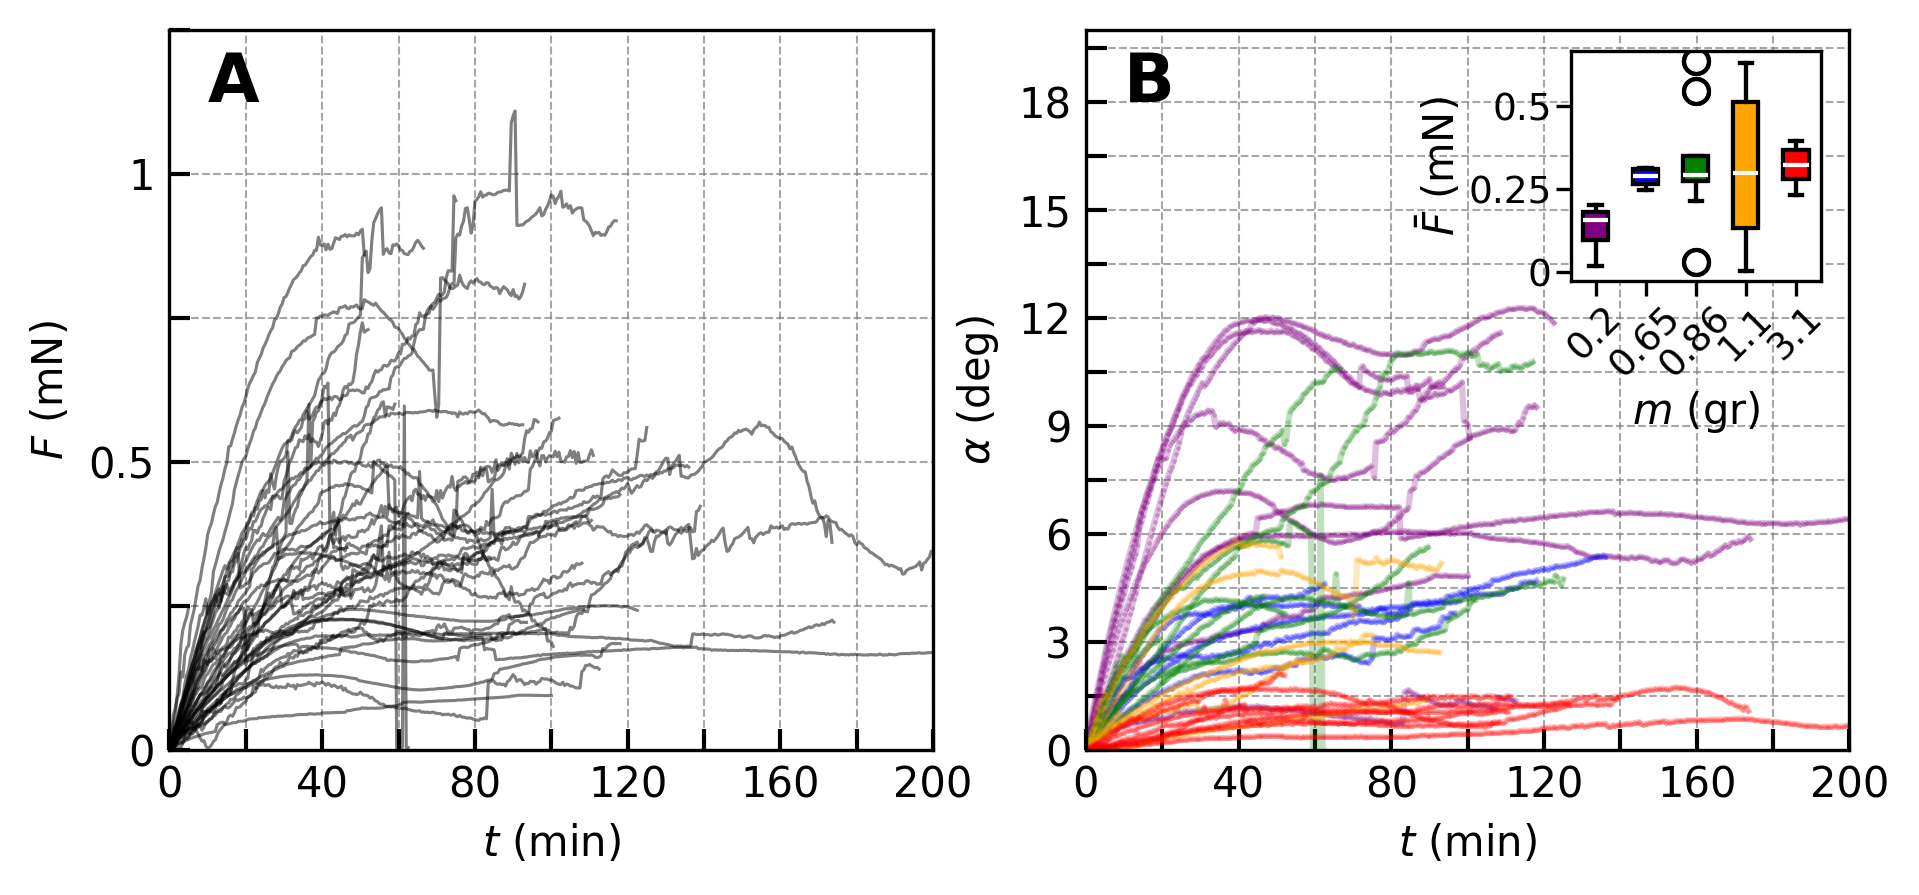

Exp Num: 110, Event Num: 1, Mass: 0.2g
Exp Num: 111, Event Num: 1, Mass: 0.2g
Exp Num: 21, Event Num: 1, Mass: 0.65g
Exp Num: 22, Event Num: 1, Mass: 0.65g
Exp Num: 51, Event Num: 1, Mass: 0.86g
Exp Num: 52, Event Num: 1, Mass: 0.86g
Exp Num: 30, Event Num: 1, Mass: 1.1g
Exp Num: 36, Event Num: 1, Mass: 1.1g
Exp Num: 55, Event Num: 1, Mass: 3.1g
Exp Num: 58, Event Num: 1, Mass: 3.1g


In [ ]:
# Plot Force trajectories (A) and angles (B)
# Rod displacement and mean force and per rod mass

cmap = plt.get_cmap('rainbow')

# filter some events by mass
mass = [0.2,0.65,0.86,1.1, 3.1]
colors = ['purple', 'blue', 'green', 'orange', 'red'] # colors for each mass
# Filter events based on rod mass and reduce every 2nd event if count exceeds 10
filtered_events = []
n_mass = 10
for ms in mass:
    events_for_mass = [event for event in events if event.p.m_sup == ms]
    if len(events_for_mass) > n_mass:
        events_for_mass = events_for_mass[:n_mass]
    print(f'Number of events for mass {ms}g: {len(events_for_mass)}')
    filtered_events.extend(events_for_mass)

# Create the figure
fig, ax = plt.subplots(1, 2, figsize=(7, 3), dpi=300)
ax[0].text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=ax[0].transAxes)
ax[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax[1].transAxes)

fs = 16
fig.align_labels()  # Align labels for all subplots

# events trajectories

for i in range(len(filtered_events)):
    ax[0].plot(filtered_events[i].timer/60, filtered_events[i].F_bean,
             color='black', alpha=0.5, linewidth = 0.75) #cmap(0.2)

# set grid and labels of main plot
set_grid(ax[0],200,2.5)
ax[0].set_ylim([0,1.25])
ax[0].set_xlim([0,200])
ax[0].set_xlabel(r'$t$ (min)')
ax[0].set_ylabel(r'$F$ (mN)') #,fontsize=fs)


# Angles and mean force and per rod mass

# all events displacements
for i in range(len(filtered_events)):
    # if filtered_events[i].event_label != 'Close2axis': continue # remove filtered_events close to axis
    if filtered_events[i].p.m_sup in mass:
        index = mass.index(filtered_events[i].p.m_sup)
        ax[1].plot(filtered_events[i].timer/60, np.rad2deg(filtered_events[i].alpha) ,marker=
                    'x',markersize=0.5,color=colors[index],alpha=0.25)
                    # 'x',markersize=0.5,color=cmap(mass[index]/max(mass)),alpha=0.25)

# set grid and labels of main plot
set_grid(ax[1],200,15)
ax[1].set_ylim([0,20])
ax[1].set_xlim([0,200])
ax[1].set_xlabel(r'$t$ (min)')
ax[1].set_ylabel(r'$\alpha$ (deg)') #,fontsize=fs)

# Ensure the x and y axes are plotted on the same scale
# ax[1].set_aspect('equal', adjustable='box')

# mean force boxplot for all filtered_events (upto the first 2 hours)
f_mean = [[] for i in range(len(mass))]
f_max = [[] for i in range(len(mass))]
for i in range(len(filtered_events)):
    
    if filtered_events[i].p.m_sup in mass:
        index = mass.index(filtered_events[i].p.m_sup)
        # check if the event is not too short
        # if filtered_events[i].frm_dec_top - filtered_events[i].frm0_top > 30:
        f_mean[index].append(np.mean(filtered_events[i].F_bean))
            # f_max[1index].append(np.max(filtered_events[i].F_bean))
# Create inset axes
ax_inset = inset_axes(ax[1], width="40%", height="40%",# loc='upper right',
                      bbox_to_anchor=(0.17, 0.2,0.82,0.8), bbox_transform=ax[1].transAxes)
# Remove missing values in f_mean
f_mean = [list(filter(lambda x: not np.isnan(x), sublist)) for sublist in f_mean]
# f_max = [list(filter(lambda x: not np.isnan(x), sublist)) for sublist in f_max]

# Add boxplots
ax_inset.boxplot(f_mean, positions=range(len(mass))) # to space the ticks by mass
# ax_inset.boxplot(f_max, positions=range(len(mass))) # to space the ticks by mass

# set box colors
# box_colors = [cmap(mass[i] / max(mass)) for i in range(len(mass))]
box_colors = colors
box = ax_inset.boxplot(f_mean, patch_artist=True, positions=range(len(mass)))
# box = ax_inset.boxplot(f_max, patch_artist=True, positions=range(len(mass)))
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
for median in box['medians']:
    median.set_color('white')  # Set the color of the median line


# Create inset of the distribution plot
ax_inset.set_xticks(range(len(mass)))
ax_inset.set_xticklabels([f'{m}' for m in mass], rotation=45)#, ha='right')
ax_inset.set_ylabel(r'$\bar{F}$ (mN)',fontsize=10,labelpad=1)
ax_inset.set_xlabel(r'$m$ (gr)',fontsize=10,labelpad=1)

# Control x-tick and y-tick positions
# ax_inset.set_xticks(mass)  # Set specific tick positions
ax_inset.set_xticklabels(mass, fontsize=9)  # Set specific tick labels with fontsize
ax_inset.set_yticks([0, 0.25, 0.5])  # Set specific y-tick positions
ax_inset.set_yticklabels([0, 0.25, 0.5], fontsize=9)  # Set specific y-tick labels with fontsize
# Adjust tick labels' padding
ax_inset.tick_params(axis='x', pad=1)  # Move x-axis labels closer to the ticks
ax_inset.tick_params(axis='y', pad=1)  # Move y-axis labels closer to the ticks

# Adjust the legend properties
# fig.legend(
#     handles=legend_elements,
#     loc='upper left',          # Place in the upper-right corner
#     frameon=False,              # Remove the frame
#     handlelength=0.8,             # Shorter line elements
#     handletextpad=0.2,          # Reduce space between handle and text
#     borderaxespad=0.1,          # Reduce space between legend and inset plot edge
#     fontsize=8                  # Smaller font size for better fit
# )

# adjust layout and show
fig.subplots_adjust(top=0.95, bottom=0.15, left=0.15, right=0.95)  # Adjust as necessary
plt.show()
# fig.savefig(save_folder + r'\F_alpha_msup.pdf', dpi=300)


# saving example files from the filtered events
# Define new folders for saving the files
track_save_folder = os.path.join(data_path, 'Example_Track')
contact_save_folder = os.path.join(data_path, 'Example_Contact')

# Create directories if they don't exist
os.makedirs(track_save_folder, exist_ok=True)
os.makedirs(contact_save_folder, exist_ok=True)

# Iterate through the first 2 events of each support mass
for ms in mass:
    events_for_mass2 = [event for event in filtered_events if event.p.m_sup == ms][:2]
    for event in events_for_mass2:
        print(f"Exp Num: {event.p.exp_num}, Event Num: {event.event_num}, Mass: {event.p.m_sup}g")

        # Save side and top tracking files
        side_files = track_dict.get((event.p.exp_num, event.event_num, 'side'), [])
        top_files = track_dict.get((event.p.exp_num, event.event_num, 'top'), [])
        for file in side_files + top_files:
            shutil.copy(file, track_save_folder)
        
        # Save contact file
        contact_file = os.path.join(data_path, 'contact_track_logs', f'CSRT_{event.p.exp_num:03d}_{event.event_num}_side_contact.txt')
        if os.path.exists(contact_file):
            shutil.copy(contact_file, contact_save_folder)



In [2]:
# Error calculations
import math as m
# tracking error is upto to ~10 pixels in side view? maybe less in top view? how to check?
# system noise determined by no-force calibration measurement. need to redo angle and force calculations for it
w = 1 # gr
dw = 0.01 # gr
g = 981 # cm/s^2
L = 20 # cm
L_vec = np.linspace(3, 30, 100) # rod length vec in cm
w_vec = np.linspace(0.3, 3, 100) # rod mass vec in gr
dL = 0.01 # cm
l_contact = 2 # cm (distance from sup. tip)
dl_contact = 0.01 # cm
alpha = 0.01 # rad
dalpha = 0.00033 # rad
F = 10 # 10 gr, 0.1 mN

# Error in force
df_w = ((F/w)**2)*(dw)**2
df_L = ((F/L)**2)*(((L*l_contact-2*L+2*l_contact)/(2*(L-l_contact)))**2)*(dL)**2
df_l_contact =((F/(L-l_contact))**2)*(dl_contact)**2
df_alpha = (((F/m.tan(alpha)+F*m.tan(alpha)))**2)*(dalpha)**2
dF = m.sqrt(df_w+df_L+df_l_contact+df_alpha)
print(f'{df_w=:.2e},{df_L=:.2e},{df_l_contact=:.2e},{df_alpha=:.2e}',f'{dF=:.2e}')



# estimate maximal mass for given force, res, and length
sigma_res = 0.014 # cm
F = 0.1 # mN
lambda_noise = np.linspace(0, 20, 1000)# noise level: [F][L] = [mN][cm]
max_mg = (4*L*F-lambda_noise)/sigma_res # in mN
# fig,ax = plt.subplots(1,1,figsize=(4, 3),dpi = 300)
# ax.plot(lambda_noise,max_mg/10,'x',markersize=0.5)
# ax.set_xlabel(r'$\lambda$ (mN*cm)')
# ax.set_ylabel('Weight (gr-force)') # 1mN ~ 0.1 gram-force
# ax.grid(True)


dD_mm=0.014 # cm
L = 19.9 # cm
alpha_min = dD_mm/L
print(f'{dD_mm=:.2f} cm, {L=:.2f} cm, {alpha_min=:.2g} rad, {np.rad2deg(alpha_min)=:.2f} deg')
w = 0.2 # gr
alpha_max = np.deg2rad(15) # rad
L_cont_min = L/4

F_res =  dD_mm*w*g/(2*L) # sigma/L * mg/2
F_max = (w*g*L/(2*(L_cont_min)))*np.tan(alpha_max) # in dyne
print(f'for {L=}, {F_res=:.2e} dyne, which is {F_res/100=:.2e}mN ~ {F_res*10=:.2e} micro-Newton')
print(f'for {L=}, {w=}, {F_max=:.2e} dyne, which is {F_max/100=:.2g}mN ')

L = 17.7 # cm
L_cont_min = L/4
w = 0.65 # gr
F_res =  dD_mm*w*g/(2*L)
F_max =w*g*L/(2*(L_cont_min))*np.tan(alpha_max) # in dyne
print(f'for {L=} cm, {w=}, F_res ~ {F_res*10=:.2e} micro-Newton')
print(f'for {L=}, {w=}, {F_max=:.2e} dyne, which is {F_max/100=:.2g}mN ')

L = 19.9 # cm
L_cont_min = L/4
w = 0.86 # gr
F_res =  dD_mm*w*g/(2*L)
F_max = w*g*L/(2*(L_cont_min))*np.tan(alpha_max) # in dyne
print(f'for {L=} cm, {w=}, F_res ~ {F_res*10=:.2e} micro-Newton')
print(f'for {L=}, {w=}, {F_max=:.2e} dyne, which is {F_max/100=:.2g}mN ')

L = 19.9 # cm
L_cont_min = L/4
w = 1.1 # gr
F_res = dD_mm*w*g/(2*L)
F_max = w*g*L/(2*(L_cont_min))*np.tan(alpha_max) # in dyne
print(f'for {L=} cm, {w=}, F_res ~ {F_res*10=:.2e} micro-Newton')
print(f'for {L=}, {w=}, {F_max=:.2e} dyne, which is {F_max/100=:.2g}mN ')

L = 19.9 # cm
L_cont_min = L/4
w = 3.1 # gr
F_res =  dD_mm*w*g/(2*L)
F_max = w*g*L/(2*(L_cont_min))*np.tan(alpha_max) # in dyne
print(f'for {L=} cm, {w=}, F_res ~ {F_res*10=:.2e} micro-Newton')
print(f'for {L=}, {w=}, {F_max=:.2e} dyne, which is {F_max/100=:.2g}mN ')

L = 100 # cm
L_cont_min = L/4
w = 50 # gr
alpha_max = np.deg2rad(15) # rad
F_res =  dD_mm*w*g/(2*L)
F_max = w*g*L/(2*(L_cont_min))*np.tan(alpha_max) # in dyne
print(f'for {L=} cm, {w=}, F_res ~ {F_res*10=:.2e} micro-Newton')
print(f'for {L=}, {w=}, {F_max=:.2e} dyne, which is {F_max/100=:.4g}mN ')

L = 10 # cm
L_cont_min = L/4
w = 0.05 # gr
alpha_max = np.deg2rad(15) # rad
F_res =  dD_mm*w*g/(2*L)
F_max = w*g*L/(2*(L_cont_min))*np.tan(alpha_max) # in dyne
print(f'for {L=} cm, {w=}, F_res ~ {F_res*10=:.2e} micro-Newton')
print(f'for {L=}, {w=}, {F_max=:.2e} dyne, which is {F_max/100=:.4g}mN ')

df_w=1.00e-02,df_L=3.09e-07,df_l_contact=3.09e-05,df_alpha=1.09e-01 dF=3.45e-01
dD_mm=0.01 cm, L=19.90 cm, alpha_min=0.0007 rad, np.rad2deg(alpha_min)=0.04 deg
for L=19.9, F_res=6.90e-02 dyne, which is F_res/100=6.90e-04mN ~ F_res*10=6.90e-01 micro-Newton
for L=19.9, w=0.2, F_max=1.05e+02 dyne, which is F_max/100=1.1mN 
for L=17.7 cm, w=0.65, F_res ~ F_res*10=2.52e+00 micro-Newton
for L=17.7, w=0.65, F_max=3.42e+02 dyne, which is F_max/100=3.4mN 
for L=19.9 cm, w=0.86, F_res ~ F_res*10=2.97e+00 micro-Newton
for L=19.9, w=0.86, F_max=4.52e+02 dyne, which is F_max/100=4.5mN 
for L=19.9 cm, w=1.1, F_res ~ F_res*10=3.80e+00 micro-Newton
for L=19.9, w=1.1, F_max=5.78e+02 dyne, which is F_max/100=5.8mN 
for L=19.9 cm, w=3.1, F_res ~ F_res*10=1.07e+01 micro-Newton
for L=19.9, w=3.1, F_max=1.63e+03 dyne, which is F_max/100=16mN 
for L=100 cm, w=50, F_res ~ F_res*10=3.43e+01 micro-Newton
for L=100, w=50, F_max=2.63e+04 dyne, which is F_max/100=262.9mN 
for L=10 cm, w=0.05, F_res ~ F_res*10=3.43

In [11]:
# parallel video example with plot and size reference
# # exp_num = 30
# event_num = 1
# find the event corresponding to exp_num and event_num:
i = 70 # 40 (simple) , 20,120 (bump from dist2tip), i=70->event 79_2
event = events[i]
# event.frm0_top = 10 # original

print(event.p.exp_num,event.event_num)
print(event.frm0_top,event.frm_dec_top)

# start video from initial contact frame for both views

# Define paths to the video frames
side_view_path = r"C:\Users\Amir\Documents\PHD\Thesis\My Articles\0_Pendulum_measured_forces\Data\Example trajectories\79_2_side\cropped"
top_view_path = r"C:\Users\Amir\Documents\PHD\Thesis\My Articles\0_Pendulum_measured_forces\Data\Example trajectories\79_2_top\cropped"
vid_path = r"C:\Users\Amir\Documents\PHD\Thesis\My Articles\0_Pendulum_measured_forces\Data\Example trajectories"

top_view_files = [os.path.join(top_view_path, f) for f in os.listdir(top_view_path) if os.path.isfile(os.path.join(top_view_path, f))]
side_view_files = [os.path.join(side_view_path, f) for f in os.listdir(side_view_path) if os.path.isfile(os.path.join(side_view_path, f))]                                                                    

# Define the number of frames
fr = 60
fr = min(fr,len(top_view_files))

top_images = top_view_files[event.frm0_top:event.frm_dec_top][:fr]
side_images = side_view_files[event.frm0_side:event.frm_dec_side][:fr]

#################
# Load coordinates from another track file in the folder
track_side_folder_path = r'C:\Users\Amir\Documents\PHD\Thesis\My Articles\0_Pendulum_measured_forces\Data\Example trajectories\79_2_side\CSRT_079_2\Rois_cropped_'
track_top_folder_path = r'C:\Users\Amir\Documents\PHD\Thesis\My Articles\0_Pendulum_measured_forces\Data\Example trajectories\79_2_top\CSRT_079_2\Rois_cropped_'

# List all files in the side and top track folders
track_side_path = os.path.join(track_side_folder_path, 'CSRT_079_side_2.txt')
track_top_path = os.path.join(track_top_folder_path, 'CSRT_079_top_2.txt')

#################
xz_track_side = funcget_tracked_data(track_side_path, [0, -1], 'side')
xy_track_top = funcget_tracked_data(track_top_path, [0, -1], 'top')

# top tracked coordiantes
x_coor_top = xy_track_top[0][event.frm0_top:event.frm_dec_top][:fr]
y_coor_top = xy_track_top[1][event.frm0_top:event.frm_dec_top][:fr]
shiftx = 100
shifty = -320
x_coor_top = np.array(x_coor_top) - shiftx
y_coor_top = np.array(y_coor_top) - shifty

# side tracked coordiantes
x_coor_side = xz_track_side[0][event.frm0_side:event.frm_dec_side][:fr]
z_coor_side = xz_track_side[1][event.frm0_side:event.frm_dec_side][:fr]
shiftz = -65
z_coor_side = np.array(z_coor_side) - shiftz
side_xz_coor = list(zip(x_coor_side,z_coor_side))
top_xy_coor = list(zip(x_coor_top,y_coor_top))

t = event.timer[event.frm0_top:event.frm_dec_top][:fr]-event.timer[event.frm0_top]
# force data
force_data = list(zip(t,event.F_bean[event.frm0_top:event.frm_dec_top][:fr]))

# parallel_video(top_images, top_xy_coor,side_images, side_xz_coor, fps=2)
display_images_with_graph3(top_images, top_xy_coor,side_images, side_xz_coor, graph_data=force_data , fps=10,
                          fixed_height=500, save_video=True, output_path=vid_path+"\\side_top_crop_f(t)_video.mp4")


#################


59 5
10 175
50
['436.0', ' 2121.0', ' 68.0', ' 83.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2.0_Methods-paper\\79_2_side\\cropped\\5775_CROPED.JPG', ' path time not found', ' 0', ' Auto\n']
50
['1687.0', ' 1212.0', ' 406.0', ' 394.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2.0_Methods-paper\\79_2_top\\cropped\\1067_CROPED.JPG', ' path time not found', ' 0', ' Auto\n']


C:\Users\Amir\AppData\Local\Temp\ipykernel_20948\1738963976.py:203: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  graph_img = np.frombuffer(canvas.tostring_rgb(), dtype="uint8")


Final frame displayed. Close the window to end.


Extras

1. angles and mean force per rod mass
2. calibration and noise
3. circumnutation distribution
4. force trajectory 
5. for trajectory with max force distribution
6. force trajectories
7. noise plot
8. measure distance
9. show event labels
10. support lengths
11. lc
12. max force and twine states
13. calibration
14. derivative
15. derivative by rod mass

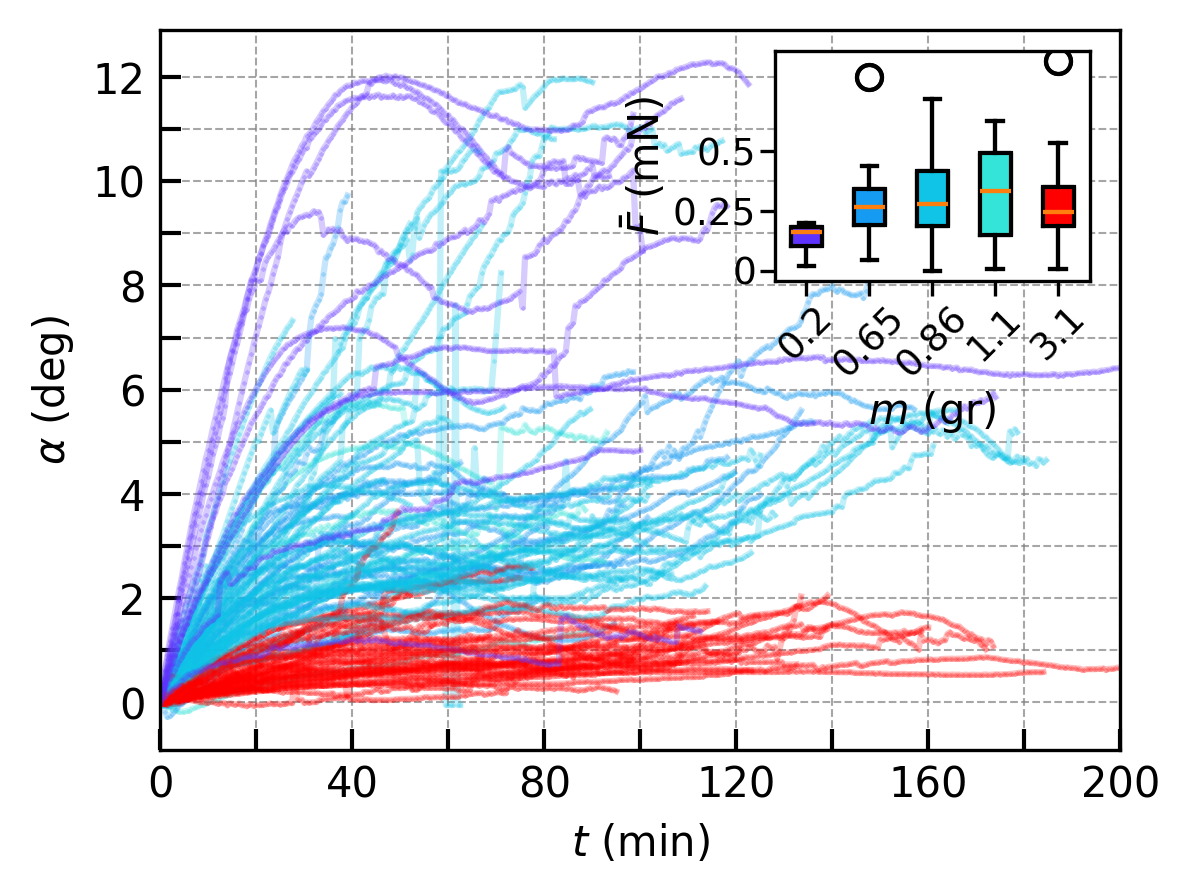

In [ ]:
# Angles and mean force and per rod mass
from matplotlib.lines import Line2D

cmap = plt.get_cmap('rainbow')
# mass = [0.2,0.65,0.86,3.1]
mass = [0.2,0.65,0.86,1.1, 3.1]

# Create the figure
fig, axs = plt.subplots(1, 1, figsize=(4, 3),dpi=300)
# fig.align_labels()  # Align labels for all subplots
# add subplot labels
# axs.text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=axs.transAxes)
# axs[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=axs[1].transAxes)

# all events displacements
for i in range(len(events)):
    # if events[i].event_label != 'Close2axis': continue # remove events close to axis
    if events[i].p.m_sup in mass:
        index = mass.index(events[i].p.m_sup)
        axs.plot(events[i].timer/60, np.rad2deg(events[i].alpha) ,marker=
                    'x',markersize=0.5,color=cmap(mass[index]/max(mass)),alpha=0.25)

# set grid and labels of main plot
set_grid(axs,200,10)
axs.set_xlim([0,200])
axs.set_xlabel(r'$t$ (min)')
axs.set_ylabel(r'$\alpha$ (deg)') #,fontsize=fs)

# Ensure the x and y axes are plotted on the same scale
# axs.set_aspect('equal', adjustable='box')

# mean force boxplot for all events (upto the first 2 hours)
f_mean = [[] for i in range(len(mass))]
f_max = [[] for i in range(len(mass))]
for i in range(len(events)):
    
    if events[i].p.m_sup in mass:
        index = mass.index(events[i].p.m_sup)
        # check if the event is not too short
        # if events[i].frm_dec_top - events[i].frm0_top > 30:
        f_mean[index].append(np.mean(events[i].F_bean))
            # f_max[index].append(np.max(events[i].F_bean))
# Create inset axes
ax_inset = inset_axes(axs, width="40%", height="40%",# loc='upper right',
                      bbox_to_anchor=(0.17, 0.2,0.82,0.8), bbox_transform=axs.transAxes)
# Remove missing values in f_mean
f_mean = [list(filter(lambda x: not np.isnan(x), sublist)) for sublist in f_mean]
# f_max = [list(filter(lambda x: not np.isnan(x), sublist)) for sublist in f_max]

# Add boxplots
ax_inset.boxplot(f_mean, positions=range(len(mass))) # to space the ticks by mass
# ax_inset.boxplot(f_max, positions=range(len(mass))) # to space the ticks by mass

# set box colors
box_colors = [cmap(mass[i] / max(mass)) for i in range(len(mass))]
box = ax_inset.boxplot(f_mean, patch_artist=True, positions=range(len(mass)))
# box = ax_inset.boxplot(f_max, patch_artist=True, positions=range(len(mass)))
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)


# Create inset of the distribution plot
ax_inset.set_xticks(range(len(mass)))
ax_inset.set_xticklabels([f'{m}' for m in mass], rotation=45)#, ha='right')
ax_inset.set_ylabel(r'$\bar{F}$ (mN)',fontsize=10,labelpad=1)
ax_inset.set_xlabel(r'$m$ (gr)',fontsize=10,labelpad=1)

# Control x-tick and y-tick positions
# ax_inset.set_xticks(mass)  # Set specific tick positions
ax_inset.set_xticklabels(mass, fontsize=9)  # Set specific tick labels with fontsize
ax_inset.set_yticks([0, 0.25, 0.5])  # Set specific y-tick positions
ax_inset.set_yticklabels([0, 0.25, 0.5], fontsize=9)  # Set specific y-tick labels with fontsize
# Adjust tick labels' padding
ax_inset.tick_params(axis='x', pad=1)  # Move x-axis labels closer to the ticks
ax_inset.tick_params(axis='y', pad=1)  # Move y-axis labels closer to the ticks

# Adjust the legend properties
# fig.legend(
#     handles=legend_elements,
#     loc='upper left',          # Place in the upper-right corner
#     frameon=False,              # Remove the frame
#     handlelength=0.8,             # Shorter line elements
#     handletextpad=0.2,          # Reduce space between handle and text
#     borderaxespad=0.1,          # Reduce space between legend and inset plot edge
#     fontsize=8                  # Smaller font size for better fit
# )

# adjust layout and show
# fig.subplots_adjust(wspace=0.4)  # Adjust the width space between subplotsplt.tight_layout()
# fig.subplots_adjust(top=0.8, bottom=0.1, left=0.1, right=0.9)  # Adjust as necessary

fig.subplots_adjust(top=0.95, bottom=0.15, left=0.15, right=0.95)  # Adjust as necessary
plt.show()
# fig.savefig(save_folder+r'\alpha_F_msup.png',dpi=300)

50
['2619.0', ' 1991.0', ' 144.0', ' 116.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Calibrations\\fluctuations_1sec_int\\DSC_8205.JPG', ' 2024-05-11 13:07', ' 0', ' Auto\n']
100
['2640.0', ' 1994.0', ' 120.0', ' 97.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Calibrations\\fluctuations_1sec_int\\DSC_8255.JPG', ' 2024-05-11 13:08', ' 0', ' Auto\n']
pix2cm=0.0019 cm/pix,std_noise=0.096 mm
d_alpha_noise=0.00029 rad , np.rad2deg(d_alpha_noise)=0.016 deg
err_res_pix=7.1 cm/pix,err_res_mm=0.13 mm
D_mm=20 mm,dD_mm=0.16 mm,L_mm=1.8e+02 mm,dL_mm=0.13 mm,h_tip_mm=12 mm,      dh_tip_mm=0.13 mm,A=0.059,alpha_error_calc=0.0005 rad, F_min_mN=0.002 mN


C:\Users\Amir\AppData\Local\Temp\ipykernel_20332\540238979.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


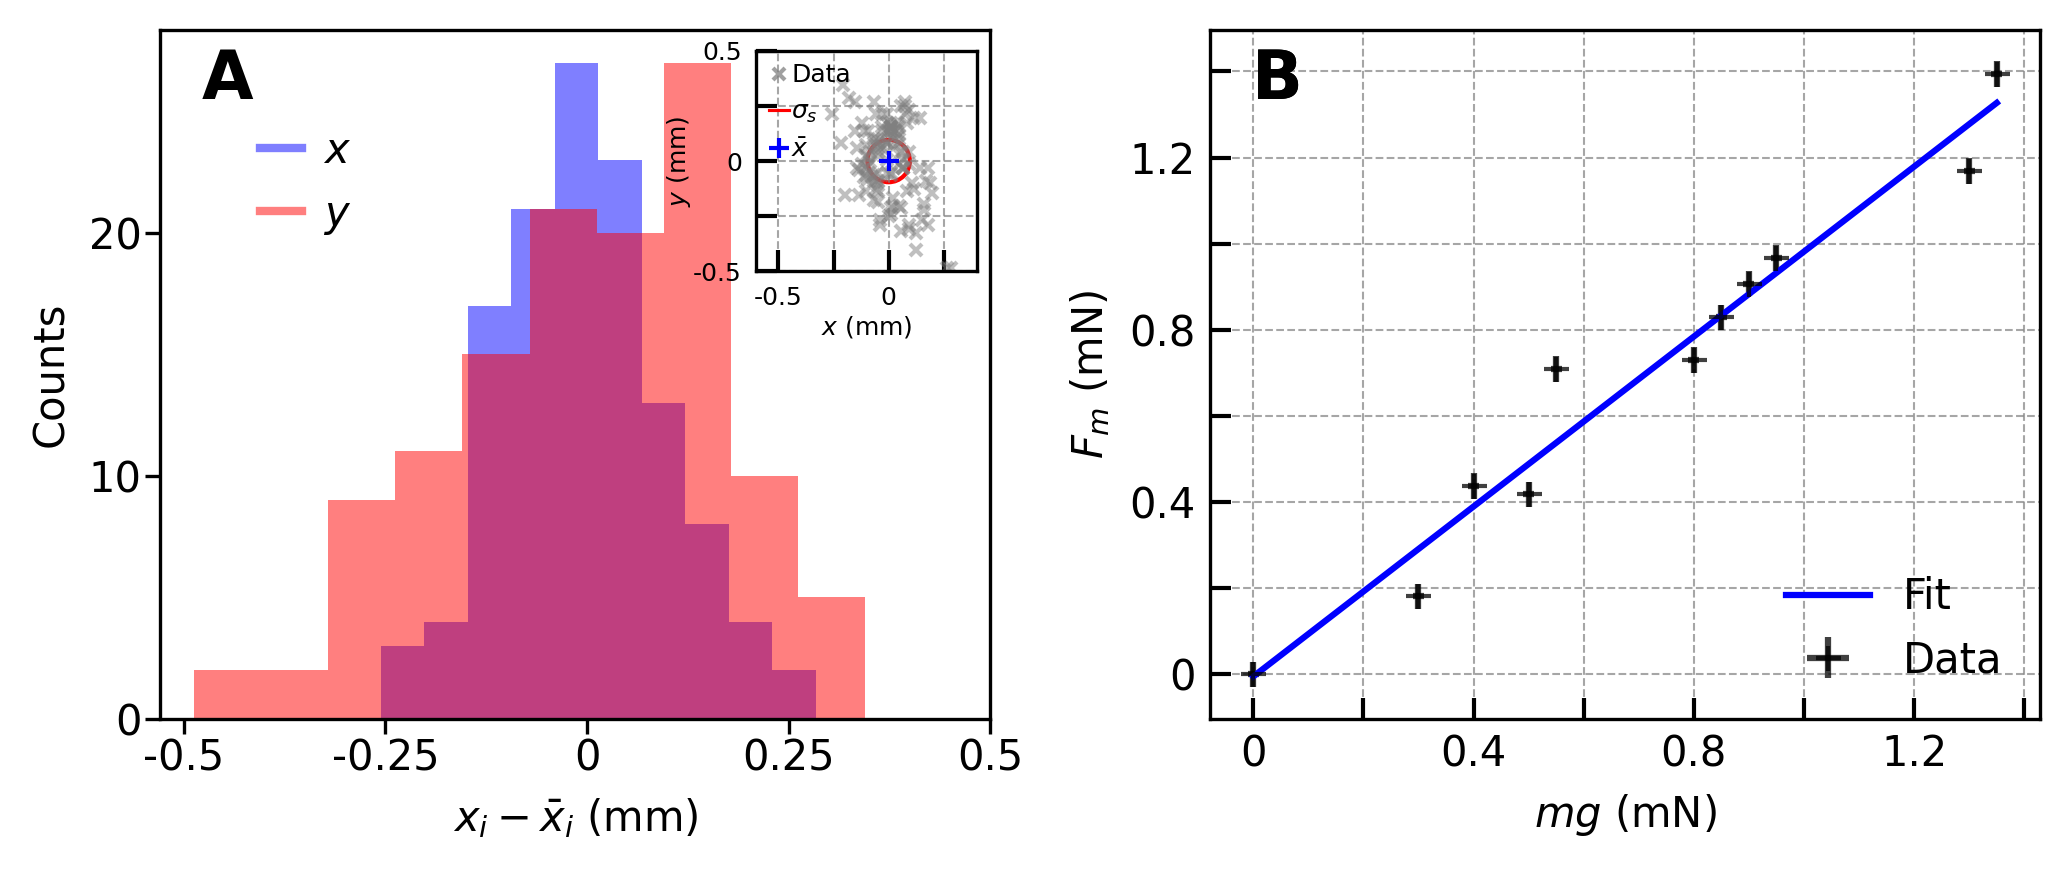

In [24]:
# combined plot of calibration (B) and noise (A)

# fluctuation_track_file = r"C:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Repo_article0\CSRT_fluctuations_1sec_interval.txt"
fluctuation_track_file = os.path.join(data_path, r'fluctuations\CSRT_fluctuations_1sec_interval.txt')
xcntr,ycntr,timer,index,N = funcget_tracked_data(fluctuation_track_file)

pend_diam_pix = 423 # width of the pendulum from top view
pend_diam_cm = 0.8
L_cm = 18 
pix2cm = pend_diam_cm/pend_diam_pix 
L_mm = L_cm*10
h_tip = np.mean([events[i].L_track2suptip_cm for i in range(len(events))])
h_tip_mm = h_tip*10

fig, ax = plt.subplots(1, 2, figsize=(7, 3), dpi=300)
ax[0].text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=ax[0].transAxes)
ax[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax[1].transAxes)


############################################################
x = np.subtract(xcntr, np.mean(xcntr))*pix2cm*10 # x10 for mm
y = np.subtract(ycntr, np.mean(ycntr))*pix2cm*10 # x10 for mm

# Plot the distribution
ax[0].hist(x, alpha=0.5, color='blue', label=r'$x$')
ax[0].hist(y, alpha=0.5, color='red', label=r'$y$')
ax[0].set_xlabel(r'$x_{i} - \bar{x}_{i}$ (mm)')
ax[0].set_ylabel('Counts')
# Control x-tick and y-tick positions
ax[0].set_xticks([-0.5, -0.25, 0, 0.25, 0.5])  # Set specific tick positions
ax[0].set_xticklabels([-0.5, -0.25, 0, 0.25, 0.5], fontsize=10)  # Set specific tick labels with fontsize
ax[0].set_yticks([0, 10, 20])  # Set specific y-tick positions
ax[0].set_yticklabels([0, 10, 20], fontsize=10)  # Set specific y-tick labels with fontsize
# Adjust tick labels' padding
ax[0].tick_params(axis='x', pad=1)  # Move x-axis labels closer to the ticks
ax[0].tick_params(axis='y', pad=1)  # Move y-axis labels closer to the ticks

# Create a custom legend element for the noise distribution
legend_elements = [
    Line2D([0], [0], color='blue',alpha=0.5, lw=2, linestyle='-', label=r'$x$'),  # Data points
    Line2D([0], [0], color='red', lw=2, alpha=0.5, linestyle='-', label=r'$y$'),  # Straight red line
]
# ax[0].legend(loc='best',frameon=False)
# Add the custom legend elements to the plot
ax[0].legend(
    handles=legend_elements,
    loc='upper left',          # Place in the upper-right corner
    frameon=False,              # Remove the frame
    handlelength=1,             # Shorter line elements
    handletextpad=0.5,          # Reduce space between handle and text
    borderaxespad=2,          # Reduce space between legend and inset plot edge
    fontsize=10                 # Smaller font size for better fit
)


############################################################
# Create inset axes
ax_inset = inset_axes(ax[0], width="40%", height="40%",# loc='upper right',
                      bbox_to_anchor=(0.22, 0.2,0.82,0.8), bbox_transform=ax[0].transAxes)
ax_inset.set_ylim([-0.5,0.5])
ax_inset.set_xlim([-0.6,0.4])
ax_inset.set_xlabel(r'$x$ (mm)',fontsize=6,labelpad=1)
ax_inset.set_ylabel(r'$y$ (mm)',fontsize=6,labelpad=0)
ax_inset.tick_params(axis='both', length=2)  # Make both x and y axis ticks shorter
ax_inset.tick_params(axis='both', width=0.5)  # Make both x and y axis ticks thinner
ax_inset.tick_params(axis='both', labelsize=6)  # Make both x and y axis labels smaller
set_grid(ax_inset,2.5,2.5)

# Increase the x and y scales of the main plot
# ax[0].set_xlim([-0.4, 0.6])
# ax[0].set_ylim([-0.3, 0.6])
# Ensure the x and y axes are plotted on the same scale
ax_inset.set_aspect('equal', adjustable='box')

# calculate the mean and standard deviation of the data
# calculate mean
ax_inset.plot(x,y,'x',color='grey',alpha=0.5,label = 'Data',markersize=3)
# plot the mean
ax_inset.plot(np.mean(x),np.mean(y),'b+',markersize=5,label={r'$\bar{x}$'})
# calculate the std
std_noise = np.std(np.sqrt(x**2 + y**2)) # in mm
# Plot a thin red circle with a radius of the standard deviation around the mean
circle_noise = plt.Circle((np.mean(x), np.mean(y)), std_noise, color='red', fill=False, linewidth=1,label=r'$\sigma_{noise}$')
# Plot a thin red circle with a radius of the pendulum around the mean
circle_diameter = plt.Circle((np.mean(x), np.mean(y)), pend_diam_cm/2*10, color='red', fill=False, linewidth=0.5)
# plt.gca().add_artist(circle_diameter)
ax_inset.add_artist(circle_noise)

# Create a custom legend element for the noise and data
legend_elements = [
    Line2D([0], [0], marker='x', color='grey', markersize=3, alpha=0.75, linestyle='None', label='Data'),  # Data points
    Line2D([0], [0], color='red', lw=0.75, linestyle='-', label=r'$\sigma_{s}$'),  # Straight red line
    Line2D([0], [0], marker='+', color='blue', markersize=5, linestyle='None', label=r'$\bar{x}$') # mean point
]

# Adjust the legend properties
ax_inset.legend(
    handles=legend_elements,
    loc='upper left',          # Place in the upper-right corner
    frameon=False,              # Remove the frame
    handlelength=0.8,           # Shorter line elements
    handletextpad=0.1,          # Reduce space between handle and text
    borderaxespad=0.1,          # Reduce space between legend and inset plot edge
    fontsize=6                  # Smaller font size for better fit
)

############################################################
# errors
std_noise = np.std(np.sqrt(x**2 + y**2)) # in mm
print(f'{pix2cm=:.2g} cm/pix,{std_noise=:.2g} mm')
d_alpha_noise = m.asin((std_noise/2)/(L_mm-h_tip_mm))
print(f'{d_alpha_noise=:.2g} rad , {np.rad2deg(d_alpha_noise)=:.2g} deg')
# error from resolution:
# distance error is ssq of individual measurement errors ~ 2 pixels per measurement
trk_pix_err = 5 # pixel tracking error estimation 
err_res_pix = m.sqrt(trk_pix_err**2 + trk_pix_err**2)
err_res_mm = err_res_pix*pix2cm*10
print(f'{err_res_pix=:.2g} cm/pix,{err_res_mm=:.2g} mm')

# sum errors from resolution and noise:
D_mm = 20 # mean deflection in mm 
dD_mm = np.sqrt(std_noise**2 + (err_res_pix*pix2cm*10)**2) # in mm
dh_tip_mm = err_res_pix*pix2cm*10
dL_mm = err_res_pix*pix2cm*10
A = D_mm/(2*(L_mm-h_tip_mm))
alpha_error_calc = 1/(1-A**2)*np.sqrt((A*dD_mm/D_mm)**2+(A*dL_mm/(L_mm-h_tip_mm))**2+(A* dh_tip_mm/(L_mm-h_tip_mm))**2)
F_min_mg = 1000*0.8 * m.tan(alpha_error_calc)/2
F_min_mN = F_min_mg * 1e-2
print(f'{D_mm=:.2g} mm,{dD_mm=:.2g} mm,{L_mm=:.2g} mm,{dL_mm=:.2g} mm,{h_tip_mm=:.2g} mm,\
      {dh_tip_mm=:.2g} mm,{A=:.2g},{alpha_error_calc=:.2g} rad, {F_min_mN=:.2g} mN')

############################################################

#%% Calibration graph for force
# file = r"C:\Users\Amir\Documents\PHD\Thesis\My Articles\0 - Flexible dynamic force measurement method via physical pendulum\Data\Force calibration data 1\force_calibration_curve.xlsx"
calibration_data_file = os.path.join(data_path, r'Force calibration\force_calibration_curve.xlsx')
calib_data = pd.read_excel(calibration_data_file)
calib_data = calib_data.dropna()

column_names = calib_data.columns
x_name = column_names[0]
y_name = column_names[1]
x = calib_data[x_name]
y = calib_data[y_name]


# plot in milli-newton: 1 dyne = 10^-5 N, 1 dyne = 100 mN
ax[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax[1].transAxes)
x_mN = x/100
y_mN = y/100
fit_w_err(ax[1],x_mN,0.01,y_mN,0.03,fit_func=linfunc, data_color = 'black',fit_color = 'blue',data_alpha = 0.75,add_legend='measure')
ax[1].legend(loc='best',frameon=False)
ax[1].set_xlabel(r'$mg$ (mN)')
ax[1].set_ylabel(r'$F_{m}$ (mN)')
set_grid(ax[1],2,2)


plt.tight_layout()
plt.show()

# adjust layout and show
# fig.subplots_adjust(wspace=0.4)  # Adjust the width space between subplotsplt.tight_layout()
fig.subplots_adjust(top=0.95, bottom=0.15, left=0.1, right=0.95)  # Adjust as necessary

fig.savefig(save_folder+r'\noise and calibration.pdf',dpi=300)

50
['2619.0', ' 1991.0', ' 144.0', ' 116.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Calibrations\\fluctuations_1sec_int\\DSC_8205.JPG', ' 2024-05-11 13:07', ' 0', ' Auto\n']
100
['2640.0', ' 1994.0', ' 120.0', ' 97.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Calibrations\\fluctuations_1sec_int\\DSC_8255.JPG', ' 2024-05-11 13:08', ' 0', ' Auto\n']
pix2cm=0.0019 cm/pix,std_noise=0.096 mm
d_alpha_noise=0.00029 rad , np.rad2deg(d_alpha_noise)=0.016 deg
D_mm=20 mm,dD_mm=0.11 mm,L_mm=1.8e+02 mm,dL_mm=0.053 mm,h_tip_mm=12 mm,      dh_tip_mm=0.053 mm,A=0.059,alpha_error_calc=0.00033 rad, F_min_mN=0.0013 mN


C:\Users\Amir\AppData\Local\Temp\ipykernel_19620\3020148921.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


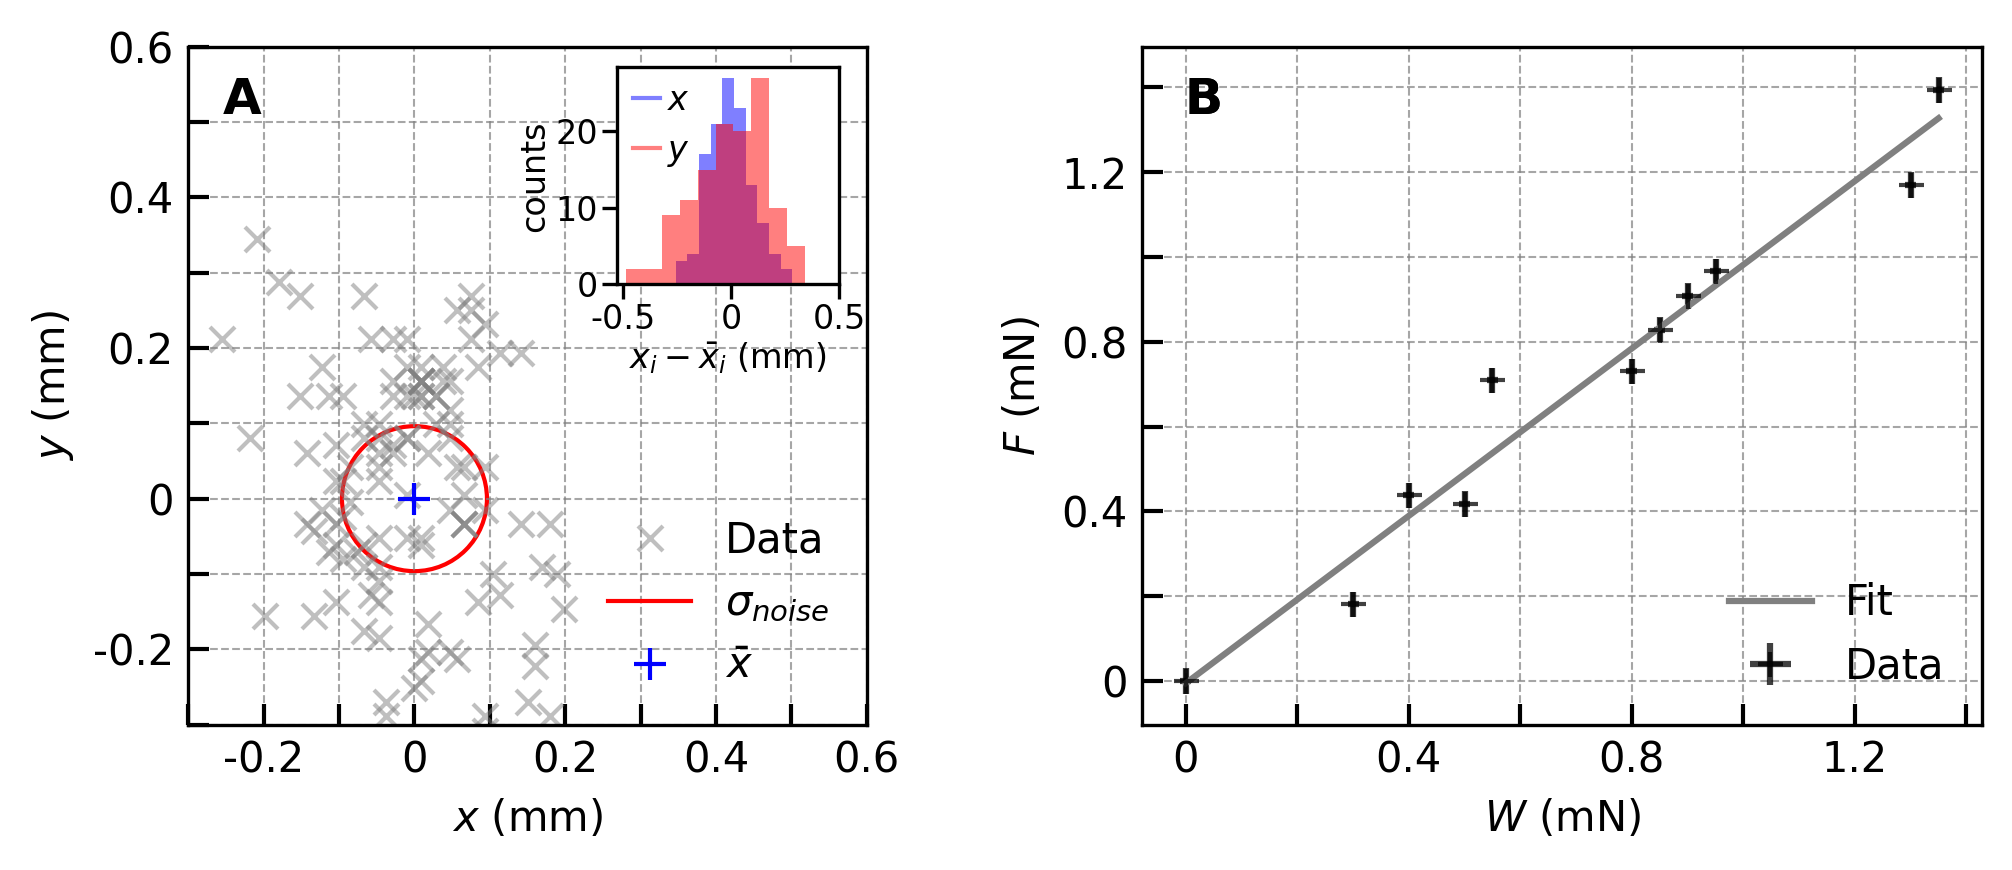

In [ ]:
# combined plot of calibration and noise

from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def funcget_tracked_data(filename,view=[],camera='nikon'):
    '''get tracked data from file, return x,y,t, N- # of lines, C-max tracked obj,T-# of points per track'''
    with open(filename,"r") as datafile:
        lines= datafile.readlines()
        # del lines[0] # remove first line to avoid 2 zero times
        N=np.size(lines,0) # number of lines
        xtl=[[]]*N # x top left
        ytl=[[]]*N # y top left
        w=[[]]*N # box width
        h=[[]]*N # box height
        xcntr=[[]]*N # box x center
        ycntr=[[]]*N # box y center
        timer = np.zeros(N) # initialize timer array
        timer[0]=0 # time starts at zero
        i=0 # count rows
    # x,y,w,h ; start at upper left corner
        for line in lines:
            if line==[]: break
            currentline = line.split(",") # split by ','
            xtl[i]=float(currentline[0]) # xtl- x top left
            ytl[i]=float(currentline[1])
            w[i]=float(currentline[2])
            h[i]=float(currentline[3])
            xcntr[i]=xtl[i]+w[i]/2 # calculate x coordinate of box center
            ycntr[i]=ytl[i]-h[i]/2
            i+=1
            if i%50 ==0: 
                print(i)
                print(currentline)

        # timer = np.zeros(N) # initialize timer array
        dt = 1 # interval
        for i in range(N):
            timer[i] = timer[i-1]+dt # assign timer value for each index
        return xcntr,ycntr,timer,N
    
test = r"C:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Repo_article0\CSRT_fluctuations_1sec_interval.txt"
xcntr,ycntr,timer,N = funcget_tracked_data(test)
pend_diam_pix = 423 # width of the pendulum from top view
pend_diam_cm = 0.8
L_cm = 18 
pix2cm = pend_diam_cm/pend_diam_pix 
L_mm = L_cm*10
h_tip = np.mean([events[i].L_track2suptip_cm for i in range(len(events))])
h_tip_mm = h_tip*10

fig, ax = plt.subplots(1, 2, figsize=(7, 3), dpi=300)
ax[0].text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=ax[0].transAxes)
ax[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax[1].transAxes)

x = np.subtract(xcntr, np.mean(xcntr))*pix2cm*10 # x10 for mm
y = np.subtract(ycntr, np.mean(ycntr))*pix2cm*10 # x10 for mm
ax[0].plot(x,y,'x',color='grey',alpha=0.5,label = 'Data')
ax[0].plot(np.mean(x),np.mean(y),'b+',markersize=7.5,label={r'$\bar{x}$'})
# Calculate the standard deviation of the points
std_noise = np.std(np.sqrt(x**2 + y**2)) # in mm

# Plot a thin red circle with a radius of the standard deviation around the mean

circle_noise = plt.Circle((np.mean(x), np.mean(y)), std_noise, color='red', fill=False, linewidth=1,label=r'$\sigma_{noise}$')
# Plot a thin red circle with a radius of the pendulum around the mean
circle_diameter = plt.Circle((np.mean(x), np.mean(y)), pend_diam_cm/2*10, color='red', fill=False, linewidth=0.5)
# plt.gca().add_artist(circle_diameter)
ax[0].add_artist(circle_noise)

# Create a custom legend element for the noise and data
legend_elements = [
    Line2D([0], [0], marker='x', color='grey', alpha=0.5, linestyle='None', label='Data'),  # Data points
    Line2D([0], [0], color='red', lw=1, linestyle='-', label=r'$\sigma_{noise}$'),  # Straight red line
    Line2D([0], [0], marker='+', color='blue', markersize=7.5, linestyle='None', label=r'$\bar{x}$') # mean point
]

# Add the custom legend elements to the plot
ax[0].legend(handles=legend_elements, loc='lower right', frameon=False)
ax[0].set_ylim([-0.2,0.4])
ax[0].set_xlim([-0.2,0.4])
# plt.ylim([-4.5,4.5])
# plt.xlim([-4.5,4.5])
ax[0].set_xlabel(r'$x$ (mm)')
ax[0].set_ylabel(r'$y$ (mm)')
# ax[0].show()


# errors
print(f'{pix2cm=:.2g} cm/pix,{std_noise=:.2g} mm')
d_alpha_noise = m.asin((std_noise/2)/(L_mm-h_tip_mm))
print(f'{d_alpha_noise=:.2g} rad , {np.rad2deg(d_alpha_noise)=:.2g} deg')
# error from resolution:
# distance error is ssq of individual measurement errors ~ 2 pixels per measurement
err_res_pix = m.sqrt(2**2 + 2**2)
err_res_mm = err_res_pix*pix2cm*10

# sum errors from resolution and noise:
D_mm = 20 # mean deflection in mm 
dD_mm = np.sqrt(std_noise**2 + (err_res_pix*pix2cm*10)**2) # in mm
dh_tip_mm = err_res_pix*pix2cm*10
dL_mm = err_res_pix*pix2cm*10
A = D_mm/(2*(L_mm-h_tip_mm))
alpha_error_calc = 1/(1-A**2)*np.sqrt((A*dD_mm/D_mm)**2+(A*dL_mm/(L_mm-h_tip_mm))**2+(A* dh_tip_mm/(L_mm-h_tip_mm))**2)
F_min_mg = 1000*0.8 * m.tan(alpha_error_calc)/2
F_min_mN = F_min_mg * 1e-2
print(f'{D_mm=:.2g} mm,{dD_mm=:.2g} mm,{L_mm=:.2g} mm,{dL_mm=:.2g} mm,{h_tip_mm=:.2g} mm,\
      {dh_tip_mm=:.2g} mm,{A=:.2g},{alpha_error_calc=:.2g} rad, {F_min_mN=:.2g} mN')

set_grid(ax[0],1,1)
# Increase the x and y scales of the main plot
ax[0].set_xlim([-0.3, 0.6])
ax[0].set_ylim([-0.3, 0.6])
# Ensure the x and y axes are plotted on the same scale
ax[0].set_aspect('equal', adjustable='box')


# Create inset of the distribution plot
# Create inset axes
ax_inset = inset_axes(ax[0], width="40%", height="40%",# loc='upper right',
                      bbox_to_anchor=(0.17, 0.2,0.82,0.8), bbox_transform=ax[0].transAxes)
# Plot the distribution on the inset
ax_inset.hist(x, alpha=0.5, color='blue', label=r'$x$')
ax_inset.hist(y, alpha=0.5, color='red', label=r'$y$')
ax_inset.set_xlabel(r'$x_{i} - \bar{x}_{i}$ (mm)',fontsize=8,labelpad=1)
ax_inset.set_ylabel('Counts',fontsize=8,labelpad=1)
# Control x-tick and y-tick positions
ax_inset.set_xticks([-0.5, 0, 0.5])  # Set specific tick positions
ax_inset.set_xticklabels([-0.5, 0, 0.5], fontsize=8)  # Set specific tick labels with fontsize
ax_inset.set_yticks([0, 10, 20])  # Set specific y-tick positions
ax_inset.set_yticklabels([0, 10, 20], fontsize=8)  # Set specific y-tick labels with fontsize
# Adjust tick labels' padding
ax_inset.tick_params(axis='x', pad=1)  # Move x-axis labels closer to the ticks
ax_inset.tick_params(axis='y', pad=1)  # Move y-axis labels closer to the ticks
# Create a custom legend element for the noise distribution
legend_elements = [
    Line2D([0], [0], color='blue',alpha=0.5, lw=1, linestyle='-', label=r'$x$'),  # Data points
    Line2D([0], [0], color='red', lw=1, alpha=0.5, linestyle='-', label=r'$y$'),  # Straight red line
]

# Adjust the legend properties
ax_inset.legend(
    handles=legend_elements,
    loc='upper left',          # Place in the upper-right corner
    frameon=False,              # Remove the frame
    handlelength=0.8,             # Shorter line elements
    handletextpad=0.2,          # Reduce space between handle and text
    borderaxespad=0.1,          # Reduce space between legend and inset plot edge
    fontsize=8                  # Smaller font size for better fit
)

#%% Calibration graph for force
file = r"C:\Users\Amir\Documents\PHD\Thesis\My Articles\0 - Flexible dynamic force measurement method via physical pendulum\Data\Force calibration data 1\force_calibration_curve.xlsx"
calib_data = pd.read_excel(file)
calib_data = calib_data.dropna()

column_names = calib_data.columns
x_name = column_names[0]
y_name = column_names[1]
x = calib_data[x_name]
y = calib_data[y_name]


# plot in milli-newton: 1 dyne = 10^-5 N, 1 dyne = 100 mN
ax[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax[1].transAxes)
x_mN = x/100
y_mN = y/100
fit_w_err(ax[1],x_mN,0.01,y_mN,0.03,fit_func=linfunc, data_color = 'black',fit_color = 'gray',data_alpha = 0.75,add_legend='measure')
ax[1].legend(loc='best',frameon=False)
ax[1].set_xlabel(r'$W$ (mN)')
ax[1].set_ylabel(r'$F$ (mN)')
set_grid(ax[1],2,2)


plt.tight_layout()
plt.show()

# adjust layout and show
# fig.subplots_adjust(wspace=0.4)  # Adjust the width space between subplotsplt.tight_layout()
fig.subplots_adjust(top=0.95, bottom=0.15, left=0.1, right=0.95)  # Adjust as necessary

# fig.savefig(save_folder+r'\calibration and noise.png',dpi=300)

min(a)=74.0,max(a)=195.625


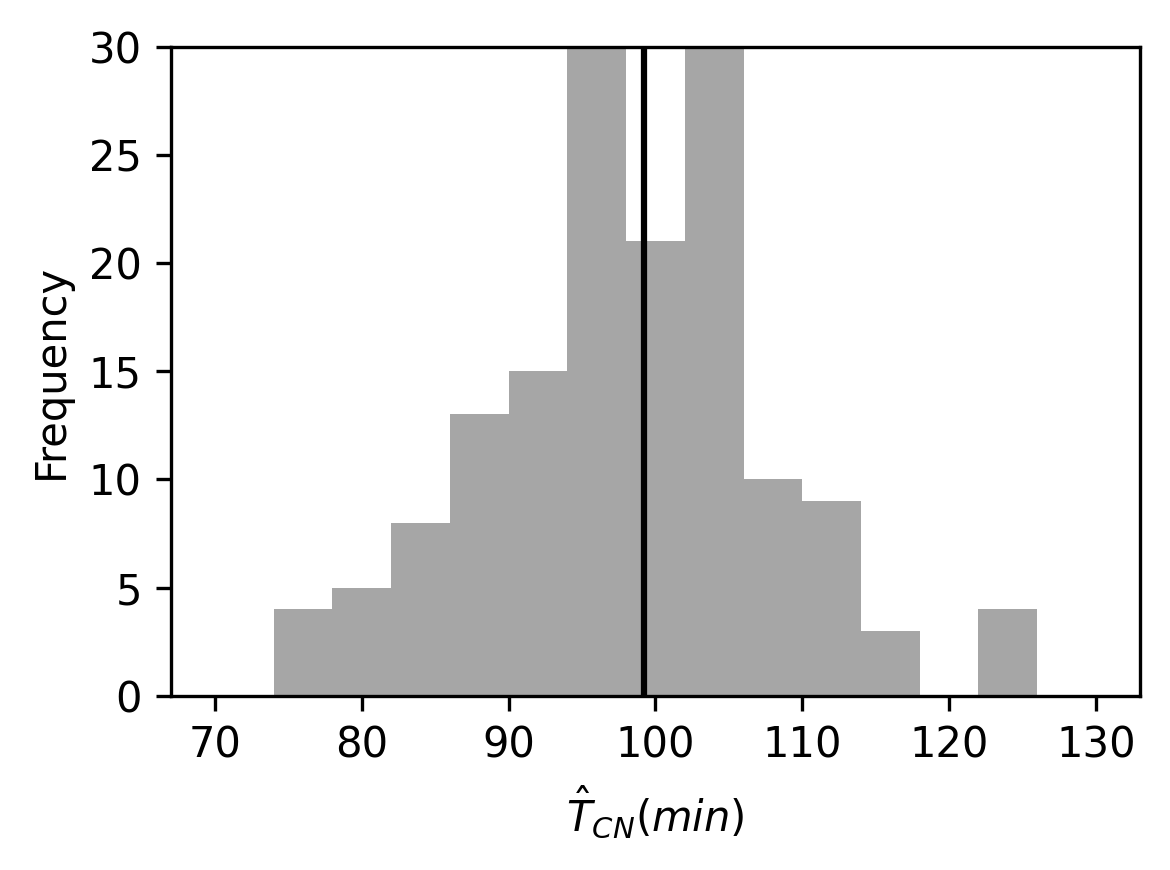

In [ ]:
# plot T_cn distribution
# this is for plants of l_arm ~ 10-20 cm
cmap = plt.get_cmap('rainbow')
fig,ax = plt.subplots(1,1, figsize=(4, 3),dpi = 300)
a = []
nbin = 15
for i in range(len(events)):
    a.append(events[i].p.avgT)
bin_range = [70,130]

n = plt.hist(a,bins=nbin,range=bin_range,color = 'gray',alpha=0.7)
plt.xlabel(r'$\hat{T}_{CN}(min)$') #,fontsize=fs)
plt.ylabel(r'Frequency')#,fontsize=fs)
plt.vlines(np.mean(a), 0, 1.1*max(a),'k')
plt.ylim([0,30])
print(f'{min(a)=},{max(a)=}')

# set_grid(plt.gca(),50,25)
plt.tight_layout()
plt.show()
# fig.savefig(save_folder+r'\CN_dist.png',dpi=300)


Slip:False


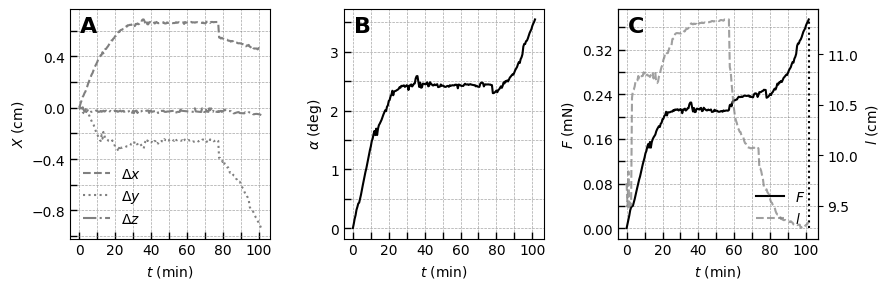

In [ ]:
# Force trajectory for slip event with contact position along support 1
# cmap = plt.get_cmap('viridis')
cmap = plt.get_cmap('rainbow')
i_slip = 20 # 40 (simple) , 20,120 
event_exmp = events[i_slip]
max_time = event_exmp.timer[-1]/60
# check events are correctly classified
print("Slip:"+ str( event_exmp.twine_state==0))

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
# add subplot labels
axs[0].text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=axs[0].transAxes)
axs[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=axs[1].transAxes)
axs[2].text(0.05, 0.9, 'C', fontsize=fs, fontweight='bold', transform=axs[2].transAxes)

# Plot xyz coordinates
xyz = event_exmp.xyz
axs[0].plot(event_exmp.timer/60, xyz[0,::]-xyz[0,0], color='gray', linestyle = 'dashed', label=r'$\Delta x$') #cmap(0.1)
axs[0].plot(event_exmp.timer/60, xyz[1,::]-xyz[1,0], color='gray', linestyle = 'dotted', label=r'$\Delta y$') #cmap(0.5)
axs[0].plot(event_exmp.timer/60, xyz[2,::]-xyz[2,0], color='gray', linestyle = 'dashdot', label=r'$\Delta z$') #cmap(0.9)

# Plot angle
axs[1].plot(event_exmp.timer/60, np.rad2deg(event_exmp.alpha), color='black', label='slip event') #cmap(0.2)
# axs[1].legend(fontsize = fs)

# Plot calculated force
# Combine legends from both axes

axs[2].plot(event_exmp.timer/60, event_exmp.F_bean, color='black', label=r'$F$') #cmap(0.2)
ax2 = axs[2].twinx()
dist2tip = [abs(k) for k in event_exmp.l_contact] # ?
# ax2.plot(event_exmp.timer/60, dist2tip, color='gray', label=r'$l$', alpha=0.75) # cmap(0.7)

axs[2].vlines(event_exmp.timer[-1]/60, 0, event_exmp.F_bean[-1], color='black', linestyle='dotted')
ax2.plot(event_exmp.timer/60, dist2tip, color='gray', linestyle='dashed', label=r'$l$', alpha=0.75)
lines, labels = axs[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axs[2].legend(lines + lines2, labels + labels2, loc='best',frameon=False)

# set axis labels and grid
axs[0].set_xlabel(r'$t$ (min)')
axs[0].set_ylabel(r'$X$ (cm)')
axs[0].legend(loc='best',frameon=False)
set_grid(axs[0],max_time,2)

axs[1].set_xlabel(r'$t$ (min)')
axs[1].set_ylabel(r'$\alpha$ (deg)')
set_grid(axs[1],max_time,5)

ax2.set_ylabel(r'$l$ (cm)')
# ax2.set_ylim([0,1])
axs[2].set_xlabel(r'$t$ (min)')
axs[2].set_ylabel(r'$F$ (mN)')
set_grid(axs[2],max_time,0.4)
# ax2.tick_params(labelsize=fs-2)
# set_grid(ax2,max_time,4)

plt.tight_layout()
plt.show()
fig.savefig(save_folder+r'\xyz_ang_F_l.png',dpi=300)


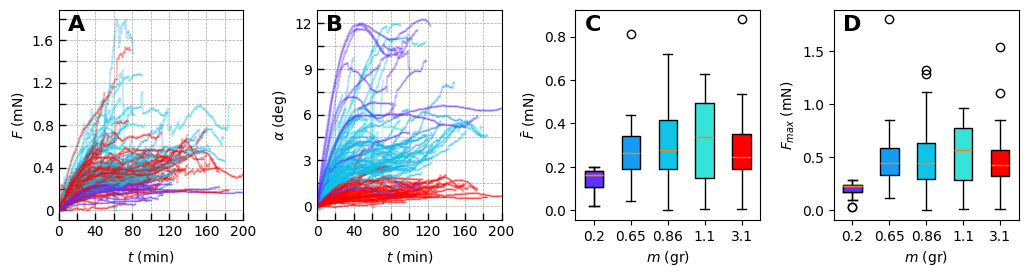

[[0.06692883287404051, 0.15990747581306322, 0.01775795335520474, 0.20115176676786478, 0.1814552958176881, 0.11973692206573076, 0.1821313856665444, 0.18700083232829187, 0.08970528661942956, 0.15389274165300332, 0.17282701996891894], [0.2657310471131681, 0.24806860083697158, 0.28886539637427106, 0.3123964040063067, 0.3104715442671663, 0.4032315078545281, 0.19125246911845523, 0.06320874652378725, 0.29542834394289363, 0.1305473358850126, 0.2151633788843863, 0.17156035577840045, 0.04355863272813297, 0.18710710073810977, 0.4188010456265159, 0.22225886820038177, 0.3734576674752994, 0.2658289604329534, 0.4090770901738622, 0.26396539953640236, 0.2495504263178024, 0.43883687442277786, 0.18005037387279443, 0.813553821361698, 0.14695265194113774, 0.4225192388364228, 0.3118334309919353], [0.3494295619309692, 0.34403592826170204, 0.2756581929251683, 0.29097309065734867, 0.21272080960235593, 0.28511282329766824, 0.03023995015534335, 0.6350533359054634, 0.5452547181549923, 0.7200791731433874, 0.460136

In [ ]:
# Force trajectory and max force distributions per support masses 1
from matplotlib.lines import Line2D

cmap = plt.get_cmap('rainbow')
# cmap = plt.get_cmap('viridis')
# mass = [0.2,0.65,0.86,3.1] # current version
mass = [0.2,0.65,0.86,1.1, 3.1] # check


# Create the figure
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
fig.align_labels()  # Align labels for all subplots
# add subplot labels
axs[0].text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=axs[0].transAxes)
axs[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=axs[1].transAxes)
axs[2].text(0.05, 0.9, 'C', fontsize=fs, fontweight='bold', transform=axs[2].transAxes)
axs[3].text(0.05, 0.9, 'D', fontsize=fs, fontweight='bold', transform=axs[3].transAxes)

# S1- all events forces
for i in range(len(events)):
    if events[i].p.m_sup in mass:
        index = mass.index(events[i].p.m_sup)
        axs[0].plot(events[i].timer/60, events[i].F_bean,marker=
                    'x',markersize=0.5,color=cmap(mass[index]/max(mass)),alpha=0.25)

# legend_elements = [Line2D([0], [0], color=cmap(mass[i]/max(mass)), lw=2, label=f'{mass[i]}') for i in range(len(mass))]
# fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1), ncol=4, title='Pendulum Mass (gr)')

# S2- all events displacements
for i in range(len(events)):
    if events[i].p.m_sup in mass:
        index = mass.index(events[i].p.m_sup)
        axs[1].plot(events[i].timer/60, np.rad2deg(events[i].alpha) ,marker=
                    'x',markersize=0.5,color=cmap(mass[index]/max(mass)),alpha=0.25)

# S3- mean force boxplot for all events (upto the first 2 hours)
f_mean = [[] for i in range(len(mass))]
f_max = [[] for i in range(len(mass))]
for i in range(len(events)):
    
    if events[i].p.m_sup in mass:
        index = mass.index(events[i].p.m_sup)
        f_mean[index].append(np.mean(events[i].F_bean))
        f_max[index].append(max(events[i].F_bean))

box_colors = [cmap(mass[i] / max(mass)) for i in range(len(mass))]

axs[2].boxplot(f_mean, positions=range(len(mass))) # to space the ticks by mass
f_mean = [list(filter(lambda x: not np.isnan(x), sublist)) for sublist in f_mean]
box = axs[2].boxplot(f_mean, patch_artist=True, positions=range(len(mass)))
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)

# S4- max force boxplot for all events (upto the first 2 hours)
axs[3].boxplot(f_max, positions=range(len(mass))) # to space the ticks by mass
f_max = [list(filter(lambda x: not np.isnan(x), sublist)) for sublist in f_max]
box = axs[3].boxplot(f_max, patch_artist=True, positions=range(len(mass)))
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)



axs[0].set_xlim([0,200])
# axs[0].set_ylim([0,1])
axs[0].set_xlabel(r'$t$ (min)')
axs[0].set_ylabel(r'$F$ (mN)')
set_grid(axs[0],200,2)

set_grid(axs[1],200,15)
axs[1].set_xlim([0,200])
axs[1].set_xlabel(r'$t$ (min)')
axs[1].set_ylabel(r'$\alpha$ (deg)') #,fontsize=fs)

axs[2].set_xticks(range(len(mass)))
axs[2].set_xticklabels([f'{m}' for m in mass], rotation=0)#, ha='right')
axs[2].set_ylabel(r'$\bar{F}$ (mN)')
axs[2].set_xlabel(r'$m$ (gr)')

axs[3].set_xticks(range(len(mass)))
axs[3].set_xticklabels([f'{m}' for m in mass], rotation=0)
axs[3].set_ylabel(r'$F_{max}$ (mN)')
axs[3].set_xlabel(r'$m$ (gr)')


# adjust layout and show
fig.subplots_adjust(wspace=0.4)  # Adjust the width space between subplotsplt.tight_layout()
fig.subplots_adjust(top=0.8, bottom=0.1, left=0.1, right=0.9)  # Adjust as necessary

plt.show()
# fig.savefig(save_folder+r'\F_D_Fmean_msup.png',dpi=300)
print(f'{f_mean}')

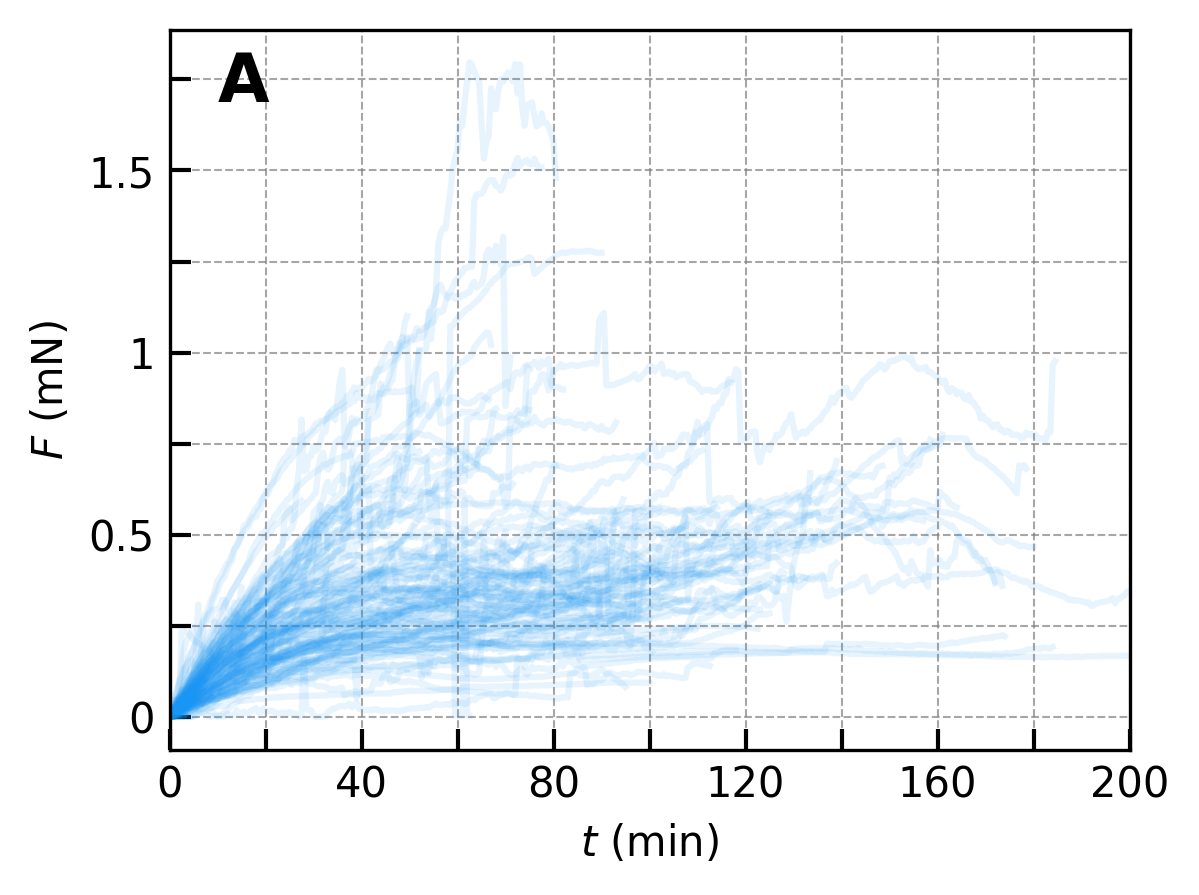

In [17]:
# Plot Force trajectories
# Rod displacement and mean force and per rod mass
from matplotlib.lines import Line2D

# Create the figure
fig, axs = plt.subplots(1, 1, figsize=(4, 3),dpi=300)
fs = 16
# fig.align_labels()  # Align labels for all subplots
# add subplot labels
axs.text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=axs.transAxes)
# axs[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=axs[1].transAxes)

# events trajectories
for i in range(len(events)):
    axs.plot(events[i].timer/60, events[i].F_bean,
             color=cmap(0.2), alpha=0.1) #cmap(0.2)

# set grid and labels of main plot
set_grid(axs,200,2.5)
axs.set_xlim([0,200])
axs.set_xlabel(r'$t$ (min)')
axs.set_ylabel(r'$F$ (mN)') #,fontsize=fs)


fig.subplots_adjust(top=0.95, bottom=0.15, left=0.15, right=0.95)  # Adjust as necessary
plt.show()
fig.savefig(save_folder+r'\F_traj.png',dpi=300)

50
['2619.0', ' 1991.0', ' 144.0', ' 116.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Calibrations\\fluctuations_1sec_int\\DSC_8205.JPG', ' 2024-05-11 13:07', ' 0', ' Auto\n']
100
['2640.0', ' 1994.0', ' 120.0', ' 97.0', ' C:\\Users\\Amir\\Documents\\PHD\\Experiments\\Force Measurements\\Exp2_Pendulum\\Calibrations\\fluctuations_1sec_int\\DSC_8255.JPG', ' 2024-05-11 13:08', ' 0', ' Auto\n']
pix2cm=0.0019 cm/pix,std_noise=0.096 mm
h_tip=1.2 cm
d_alpha_noise=0.00029 rad , np.rad2deg(d_alpha_noise)=0.016 deg
D_mm=20 mm,dD_mm=0.11 mm,L_mm=1.8e+02 mm,dL_mm=0.053 mm,h_tip_mm=12 mm,      dh_tip_mm=0.053 mm,A=0.059,alpha_error_calc=0.00033 rad, np.rad2deg(alpha_error_calc)=0.019 deg, F_min_mN=0.0013 mN


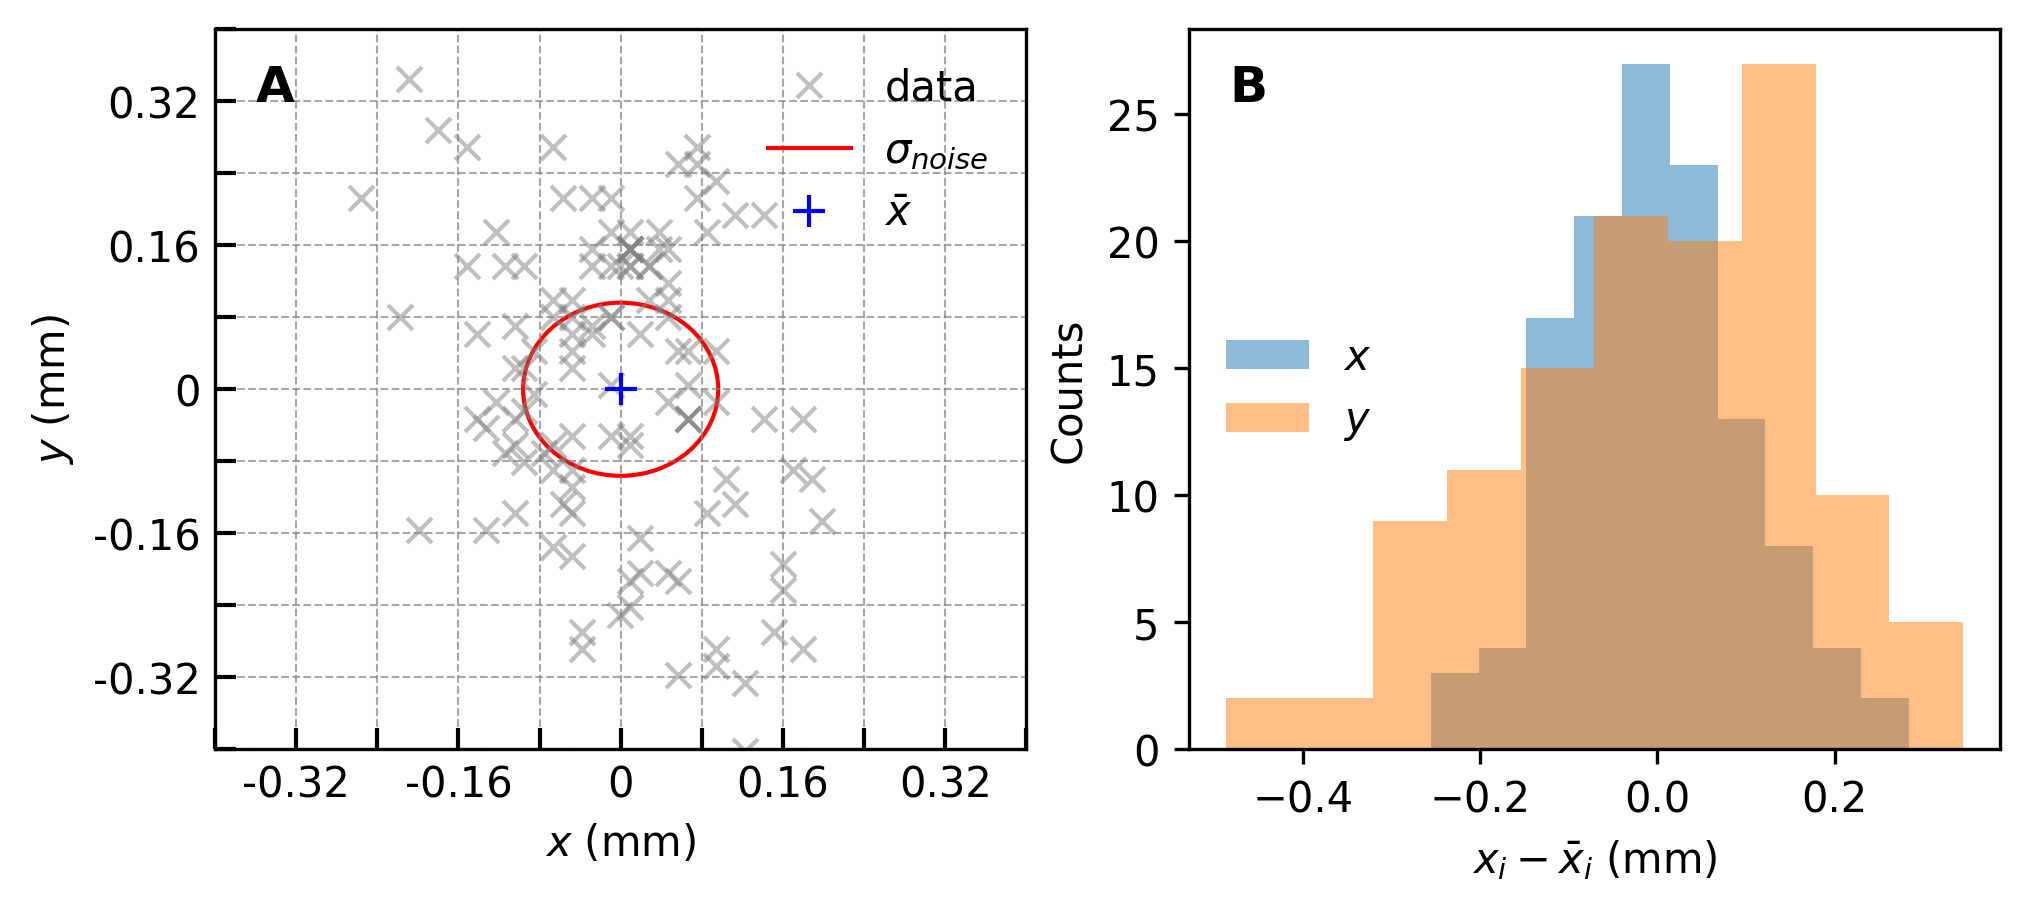

In [ ]:
# noise plots 1

from matplotlib.lines import Line2D


def funcget_tracked_data(filename,view=[],camera='nikon'):
    '''get tracked data from file, return x,y,t, N- # of lines, C-max tracked obj,T-# of points per track'''
    with open(filename,"r") as datafile:
        lines= datafile.readlines()
        # del lines[0] # remove first line to avoid 2 zero times
        N=np.size(lines,0) # number of lines
        xtl=[[]]*N # x top left
        ytl=[[]]*N # y top left
        w=[[]]*N # box width
        h=[[]]*N # box height
        xcntr=[[]]*N # box x center
        ycntr=[[]]*N # box y center
        timer = np.zeros(N) # initialize timer array
        timer[0]=0 # time starts at zero
        i=0 # count rows
    # x,y,w,h ; start at upper left corner
        for line in lines:
            if line==[]: break
            currentline = line.split(",") # split by ','
            xtl[i]=float(currentline[0]) # xtl- x top left
            ytl[i]=float(currentline[1])
            w[i]=float(currentline[2])
            h[i]=float(currentline[3])
            xcntr[i]=xtl[i]+w[i]/2 # calculate x coordinate of box center
            ycntr[i]=ytl[i]-h[i]/2
            i+=1
            if i%50 ==0: 
                print(i)
                print(currentline)

        # timer = np.zeros(N) # initialize timer array
        dt = 1 # interval
        for i in range(N):
            timer[i] = timer[i-1]+dt # assign timer value for each index
        return xcntr,ycntr,timer,N
    
test = r"C:\Users\Amir\Documents\PHD\Python\GitHub\Amir_Repositories\Repo_article0\CSRT_fluctuations_1sec_interval.txt"
xcntr,ycntr,timer,N = funcget_tracked_data(test)
pend_diam_pix = 423 # width of the pendulum from top view
pend_diam_cm = 0.8
L_cm = 18 
pix2cm = pend_diam_cm/pend_diam_pix 
L_mm = L_cm*10
h_tip = np.mean([events[i].L_track2suptip_cm for i in range(len(events))])
h_tip_mm = h_tip*10

fs = 12
fig, ax = plt.subplots(1, 2, figsize=(7, 3), dpi=300)
ax[0].text(0.05, 0.9, 'A', fontsize=fs, fontweight='bold', transform=ax[0].transAxes)
ax[1].text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax[1].transAxes)

x = np.subtract(xcntr, np.mean(xcntr))*pix2cm*10 # x10 for mm
y = np.subtract(ycntr, np.mean(ycntr))*pix2cm*10 # x10 for mm
ax[0].plot(x,y,'x',color='grey',alpha=0.5,label = 'data')
ax[0].plot(np.mean(x),np.mean(y),'b+',markersize=7.5,label={r'$\bar{x}$'})
# Calculate the standard deviation of the points
std_noise = np.std(np.sqrt(x**2 + y**2)) # in mm

# Plot a thin red circle with a radius of the standard deviation around the mean

circle_noise = plt.Circle((np.mean(x), np.mean(y)), std_noise, color='red', fill=False, linewidth=1,label=r'$\sigma_{noise}$')
# Plot a thin red circle with a radius of the pendulum around the mean
circle_diameter = plt.Circle((np.mean(x), np.mean(y)), pend_diam_cm/2*10, color='red', fill=False, linewidth=0.5)
# plt.gca().add_artist(circle_diameter)
ax[0].add_artist(circle_noise)

# Create a custom legend element for the noise and data
legend_elements = [
    Line2D([0], [0], marker='x', color='grey', alpha=0.5, linestyle='None', label='data'),  # Data points
    Line2D([0], [0], color='red', lw=1, linestyle='-', label=r'$\sigma_{noise}$'),  # Straight red line
    Line2D([0], [0], marker='+', color='blue', markersize=7.5, linestyle='None', label=r'$\bar{x}$') # mean point
]

# Add the custom legend elements to the plot
ax[0].legend(handles=legend_elements, loc='best', frameon=False)
ax[0].set_ylim([-0.4,0.4])
ax[0].set_xlim([-0.4,0.4])
# plt.ylim([-4.5,4.5])
# plt.xlim([-4.5,4.5])
ax[0].set_xlabel(r'$x$ (mm)')
ax[0].set_ylabel(r'$y$ (mm)')
# ax[0].show()

print(f'{pix2cm=:.2g} cm/pix,{std_noise=:.2g} mm')

ax[1].hist(x,alpha=0.5,label=r'$x$')
ax[1].hist(y,alpha=0.5,label=r'$y$')
ax[1].set_xlabel(r'$x_{i} - \bar{x}_{i}$ (mm)')
ax[1].set_ylabel('Counts')  
ax[1].legend(loc='best', frameon=False)
print(f'{h_tip=:.2g} cm')

d_alpha_noise = m.asin((std_noise/2)/(L_mm-h_tip_mm))
print(f'{d_alpha_noise=:.2g} rad , {np.rad2deg(d_alpha_noise)=:.2g} deg')

# error from resolution:
# distance error is ssq of individual measurement errors ~ 2 pixels per measurement ?
err_res_pix = m.sqrt(2**2 + 2**2)
err_res_mm = err_res_pix*pix2cm*10

# d_alpha_res = m.asin((err_res_mm/2)/(L_mm-h_tip_mm))
# print(f'{d_alpha_res=:.2g} rad , {np.rad2deg(d_alpha_res)=:.2g} deg')


# sum errors from resolution and noise:
# d_alpha_tot = m.sqrt(d_alpha_res**2+d_alpha_noise**2) # deg
# print(f'{d_alpha_tot=:.2g} rad , {np.rad2deg(d_alpha_tot)=:.2g} deg')
D_mm = 20 # mean deflection in mm 
dD_mm = np.sqrt(std_noise**2 + (err_res_pix*pix2cm*10)**2) # in mm
dh_tip_mm = err_res_pix*pix2cm*10
dL_mm = err_res_pix*pix2cm*10
A = D_mm/(2*(L_mm-h_tip_mm))
alpha_error_calc = 1/(1-A**2)*np.sqrt((A*dD_mm/D_mm)**2+(A*dL_mm/(L_mm-h_tip_mm))**2+(A* dh_tip_mm/(L_mm-h_tip_mm))**2)
F_min_mg = 1000*0.8 * m.tan(alpha_error_calc)/2
F_min_mN = F_min_mg * 1e-2
print(f'{D_mm=:.2g} mm,{dD_mm=:.2g} mm,{L_mm=:.2g} mm,{dL_mm=:.2g} mm,{h_tip_mm=:.2g} mm,\
      {dh_tip_mm=:.2g} mm,{A=:.2g},{alpha_error_calc=:.2g} rad, {np.rad2deg(alpha_error_calc)=:.2g} deg, {F_min_mN=:.2g} mN')

set_grid(ax[0],0.8,0.8)
# set_grid(ax[1],1,25)

# adjust layout and show
# fig.subplots_adjust(wspace=0.4)  # Adjust the width space between subplotsplt.tight_layout()
fig.subplots_adjust(top=0.95, bottom=0.15, left=0.1, right=0.95)  # Adjust as necessary

fig.savefig(save_folder+r'\noise.png',dpi=300)

In [40]:
# measure distance on specific img
from useful_functions import live_line, distance_2d
filename = r"C:\Users\Amir\Documents\PHD\Experiments\Force Measurements\Exp2_Pendulum\minsc_photos\initial\026_side.JPG"
line = []
live_line(filename,'contact distance',line) # press q to finish
sumlen = 0
for l in line: # sum all lines drawn
    sumlen += distance_2d(l) # sum over all lines
print(sumlen)

470


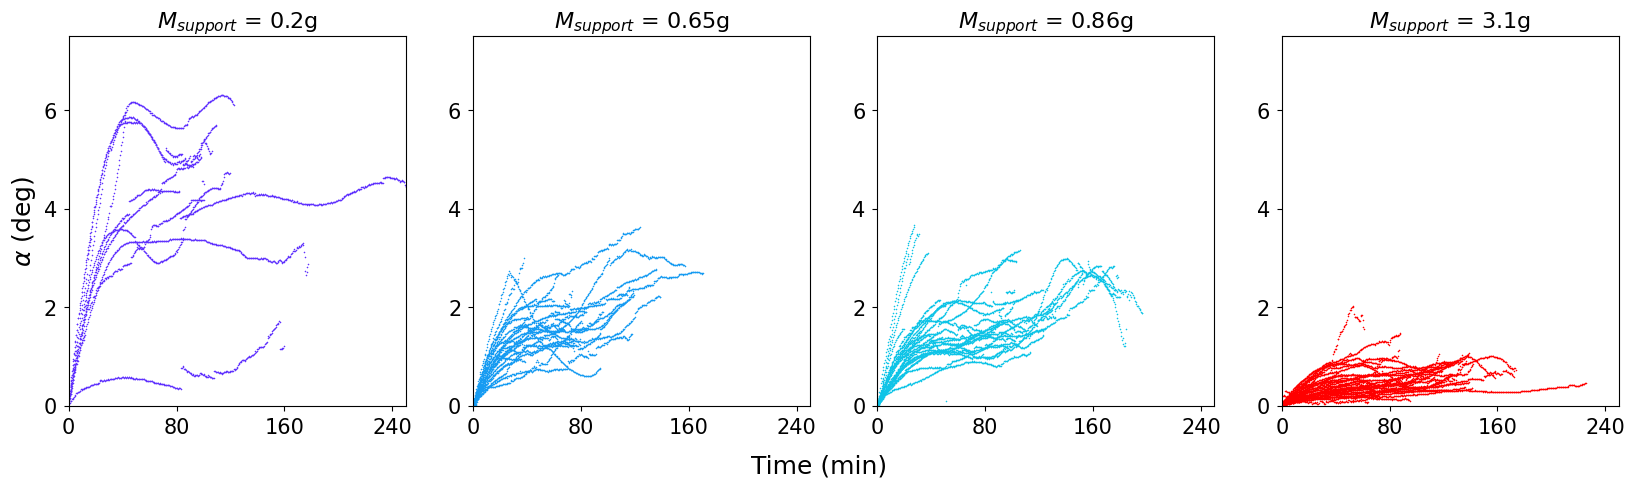

In [ ]:
# Plot trajectories for different support masses
mass = [0.2,0.65,0.86,3.1]

fig, ax = plt.subplots(1, 4)
fig.set_figwidth(20)
fig.text(0.5, -0.03, 'Time (min)', ha='center', fontsize=fs+2)
for i in range(len(mass)):
    # ax[i].set_ylim([0, 0.125])
    ax[i].set_ylim([0, 7.5])
    # ax[i].set_xlim([0, 12500])
    ax[i].set_xlim([0, 250])
    ax[i].tick_params(axis='both', which='major', labelsize=fs-1)
    ax[i].xaxis.set_major_locator(plt.MaxNLocator(4))
    ax[i].yaxis.set_major_locator(plt.MaxNLocator(4))
    ax[i].xaxis.set_tick_params(pad=5)
    ax[i].yaxis.set_tick_params(pad=5)
    ax[i].set_title(r'$M_{support}$'+f' = {mass[i]}g' , fontsize=fs)
ax[0].set_ylabel(r"$\alpha$ (deg)", fontsize=fs+2)
for i in range(len(events)):
    if events[i].p.m_sup in mass:
        index = mass.index(events[i].p.m_sup)
        ax[index].plot(events[i].timer/60, np.rad2deg(events[i].alpha),
                       'x',markersize=0.5,color=cmap(mass[index]/max(mass)))
#%%

In [33]:
# show event labels
label_categories = {}
for i in range(len(events)):
    label = events[i].event_label
    if label in label_categories.keys():
        label_categories[label].append(i)
    else:
        label_categories[label] = [i]
# Count the number of events per category
for label, indices in label_categories.items():
    print(f"Category '{label}': {len(indices)} events")   
    
print(len(events))

Category 'nan': 139 events
Category 'Close2axis': 23 events
162


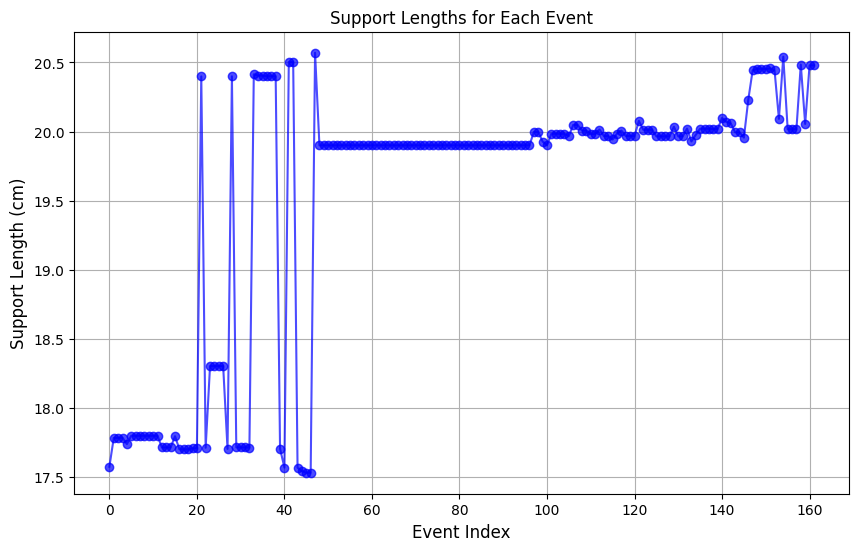

In [84]:
# Extract support lengths from each event
support_lengths = [event.p.Lsup_cm for event in events]
# Print the variables in events
# for event in events:
    # print(vars(event.p).keys())
# Plot the support lengths
plt.figure(figsize=(10, 6))
plt.plot(support_lengths, 'o-', color='blue', alpha=0.7)
plt.xlabel('Event Index', fontsize=fs)
plt.ylabel('Support Length (cm)', fontsize=fs)
plt.title('Support Lengths for Each Event', fontsize=fs)
plt.grid(True)
plt.show()

k=112

for i in range(len(events)): 
        if events[i].p.Lsup_cm >21:
            print(events[i].p.exp_num,events[i].event_num)


IndexError: list index out of range

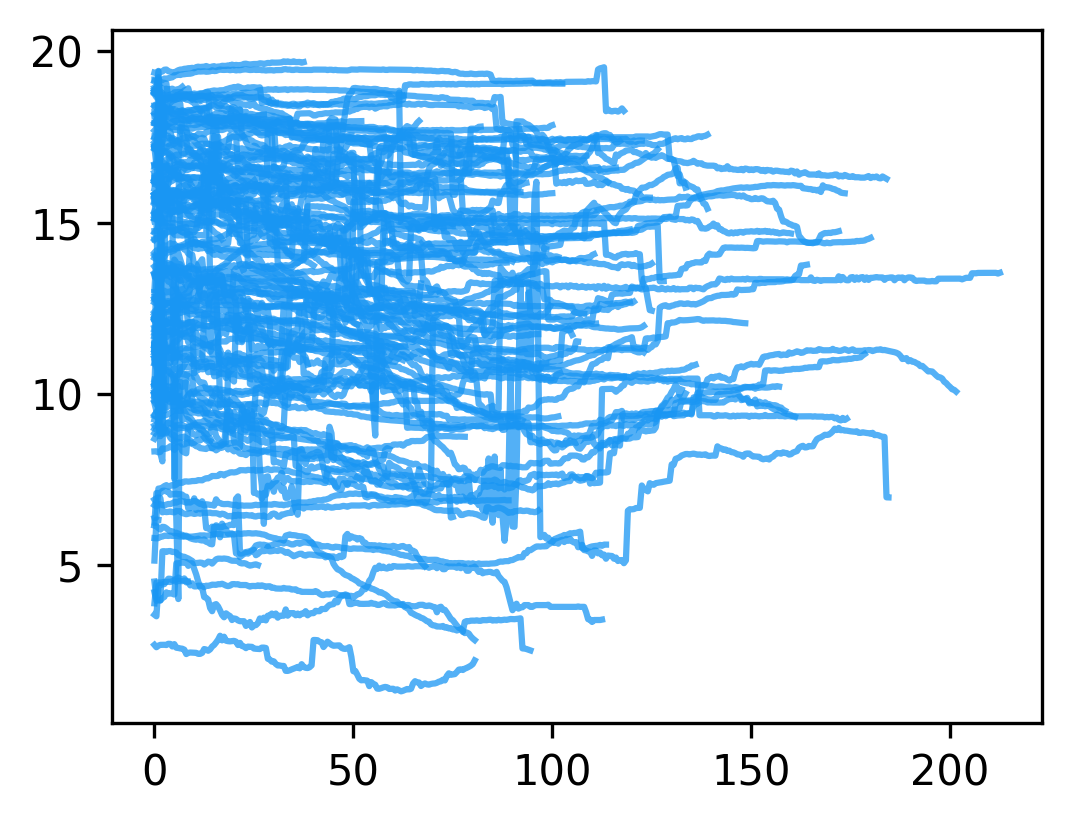

In [ ]:
# lc (distance from hinge) plots

fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300)
for i in range(180):
    ax.plot(events[i].timer/60, events[i].l_contact, color= cmap(0.2), alpha=0.75)

 

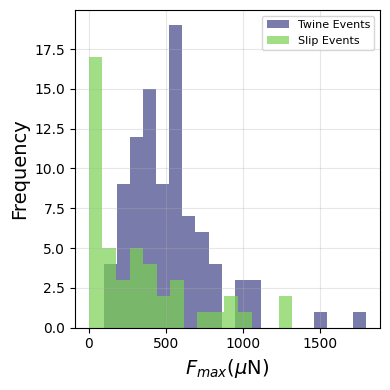

done


In [14]:
# Extract maximal forces and twine states
max_forces = [max(event.F_bean) for event in events]
twine_states = [event.twine_state for event in events]  # Assuming 1 for twine, 0 for non-twine
cmap = plt.get_cmap('viridis')
# Separate forces based on twine state
twine_forces = [1e3*force for force, state in zip(max_forces, twine_states) if state == 1]
non_twine_forces = [1e3*force for force, state in zip(max_forces, twine_states) if state == 0]

# Plot histogram
plt.figure(figsize=(4, 4))
plt.hist(twine_forces, bins=20, alpha=0.7, label='Twine Events', color=cmap(0.2))
plt.hist(non_twine_forces, bins=15, alpha=0.7, label='Slip Events', color=cmap(0.8))

# Add labels and legend
plt.xlabel(r'$F_{max} $($\mu $N)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(loc='upper right', fontsize=8)
plt.grid(alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()
print('done')

popt=array([ 0.98636788, -0.00471318]),pcov=array([[ 0.00058263, -0.00041843],
       [-0.00041843,  0.00039142]]),chi_squared_red=8.72e+00,chi_sr_std=5.00e-01,r_squared=9.60e-01


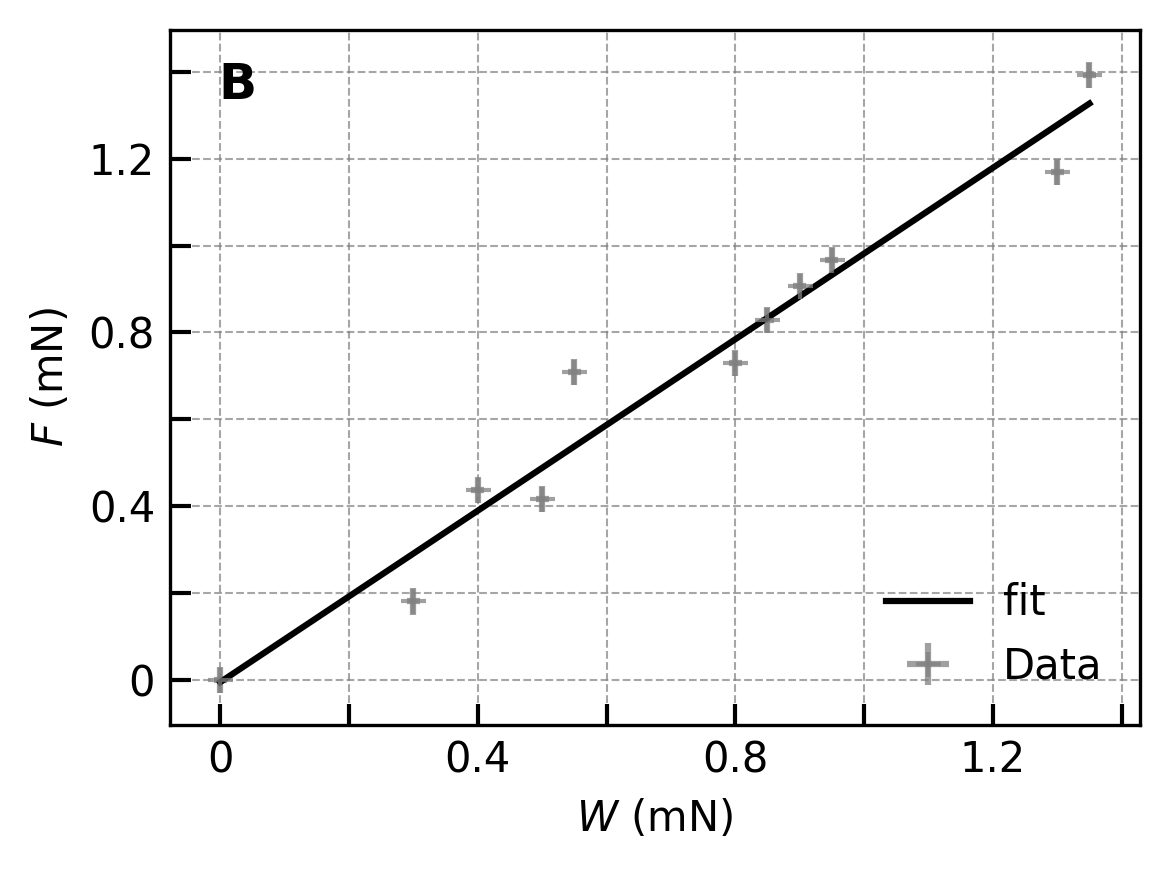

In [ ]:
# Calibration graph for force
file = r"C:\Users\Amir\Documents\PHD\Thesis\My Articles\0 - Flexible dynamic force measurement method via physical pendulum\Data\Force calibration data 1\force_calibration_curve.xlsx"
calib_data = pd.read_excel(file)
calib_data = calib_data.dropna()

column_names = calib_data.columns
x_name = column_names[0]
y_name = column_names[1]
x = calib_data[x_name]
y = calib_data[y_name]


# plot in milli-newton: 1 dyne = 10^-5 N, 1 dyne = 100 mN
fig,ax = plt.subplots(1,1,figsize=(4, 3),dpi = 300)
ax.text(0.05, 0.9, 'B', fontsize=fs, fontweight='bold', transform=ax.transAxes)

ax = plt.gca()
x_mN = x/100
y_mN = y/100
fit_w_err(ax,x_mN,0.01,y_mN,0.03,fit_func=linfunc, data_color = 'gray',fit_color = 'black',data_alpha = 0.75,add_legend='measure')
plt.legend(loc='best',frameon=False)
plt.xlabel(r'$W$ (mN)')
plt.ylabel(r'$F$ (mN)')
set_grid(ax,2,2)
plt.tight_layout()
plt.show()
fig.savefig(save_folder+r'\calibration.png',dpi=300)

In [ ]:
print('hello world')


hello world
